In this notebook, we ran scope for the C-H arylation dataset.

NOTE: As this dataset only served illustrative purposes that the algorithm can be used for multi-objective scenarios, only 20 random seeds were used.

In [1]:

from pathlib import Path
import os
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.lines import Line2D
import colorsys
import numpy as np
import pandas as pd
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import cdist
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import scale
from umap import UMAP
sys.path.append(os.path.abspath(os.path.join('..','..','..')))
from Code.benchmark import Benchmark
from Code.predictor import ScopeBO


# Doyle colors
doyle_colors = ["#CE4C6F", "#1561C2", "#188F9D","#C4ADA2","#515798", "#CB7D85", "#A9A9A9"]
# extension of palette with lighter and darker versions
def adjust_lightness(color, factor=1.2):
    """
    Function to make colors lighter (factor > 1) or darker (factor < 1).
    """
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, l * factor))
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return mcolors.to_hex((r, g, b))

lighter = [adjust_lightness(c, 1.2) for c in doyle_colors]
darker  = [adjust_lightness(c, 0.7) for c in doyle_colors]
all_colors = doyle_colors + darker[::-1] + lighter[::-1] 

# Save the categorical colormap
cat_cmap = ListedColormap(all_colors, name="Doyle_cat")
plt.colormaps.register(cat_cmap)

# Define and save a continuous colormap
colors = [doyle_colors[1],"#FFFFFFD1",doyle_colors[0]]
cont_cmap = LinearSegmentedColormap.from_list("Doyle_cont", colors)
plt.colormaps.register(cont_cmap)

wdir = Path(".")

# General plt parameters
plt.rcParams.update({
    "axes.titlesize": 20,        # Subplot title
    "axes.labelsize": 16,        # X and Y labels
    "figure.titlesize": 24,      # Suptitle
    "xtick.labelsize": 14,       # X tick labels
    "ytick.labelsize": 14,       # Y tick labels
    "legend.fontsize": 14,       # Legend text
    "legend.title_fontsize": 14  # Legend titles
})

# Scope score definition

In order to calculate scope scores for this dataset, we first established objective bounds for the normalization of them using the workflow established in the hyperparameter optimization for the ArI oxidative addtion dataset.

In [2]:
# Read in the labelled dataset and scale it
df_labelled = pd.read_csv(f"./arylation_labelled_data.csv", index_col=0,header=0)
df_data = df_labelled.copy(deep=True)
df_data = df_data.drop(columns=['yield','cost'])  # drop the objective values
df_data = pd.DataFrame(scale(df_data),df_data.index,df_data.columns)
objectives = ["yield","cost"]
wdir = Path(".")

# Make a UMAP for visualization of the results
fit = UMAP(n_neighbors=40,min_dist=0.7,n_components=2,metric="euclidean",random_state=12)
df_umap = pd.DataFrame(fit.fit_transform(df_data),df_data.index,["UMAP1","UMAP2"])
df_umap.to_csv("arylation_UMAP_coords.csv")


Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
Graph is not fully connected, spectral embedding may not work as expected.


In [3]:
# # High vendi and low objective bounds with the explorative acquisition function with max pruning for the respective batch size
# # run_settings = {1: 0, 3: 0, 4: 0,2: 0}
# run_settings = {1: 0, 3: 0, 4: 0}
# NOTE: Batch size 2 skipped because it gave numerical errors

# for batch_size in run_settings.keys():
#     Benchmark().collect_data(
#         filename_labelled = f"./arylation_labelled_data.csv",
#         name_results = f"./Results_Data/bounds/greedy40_b{batch_size}",
#         objectives=['yield',"cost"],
#         objective_mode={'cost':"min"},  # code assumes maximization for all non-listed objectives
#         budget = 40,
#         batches= [batch_size],
#         Vendi_pruning_fractions = [run_settings[batch_size]],
#         seeds = 20,
#         acquisition_function_mode= "greedy",
#         pruning_metric= "vendi_batch",
#         init_sampling_method="random")

In [4]:
# # High vendi and low objective bounds with the explorative acquisition function with max pruning for the respective batch size
# run_settings = {1: 11, 3: 33, 4: 43, 2: 23}
# for batch_size in run_settings.keys():
#     Benchmark().collect_data(
#         filename_labelled = f"./arylation_labelled_data.csv",
#         name_results = f"./Results_Data/bounds/explorative40_b{batch_size}",
#         objectives=['yield',"cost"],
#         objective_mode={'cost':"min"},  # code assumes maximization for all non-listed objectives
#         budget = 40,
#         batches= [batch_size],
#         Vendi_pruning_fractions = [run_settings[batch_size]],
#         seeds = 20,
#         acquisition_function_mode= "explorative",
#         pruning_metric= "vendi_batch",
#         init_sampling_method="random")

Get the objective and Vendi score bounds by analyzing the scopes

In [5]:
# Use the results of the explorative acqusition function (max pruning) with scope size 40, to get the lower bounds for the yield and the upper bounds for the cost 
# (as it is a minimization task) and the vendi score.
dfs_bounds_greedy = {}
objective_mode = "max"
for metric in ["yield","cost","vendi"]:
    dfs_metric = {}
    for batch_size in [1,3,4]:
        dfs_metric[batch_size] = Benchmark().heatmap_plot(type_results=metric,name_results=f"./Results_Data/bounds/greedy40_b{batch_size}",budget=40,show_plot=False)
    greedy_values = pd.concat(dfs_metric,axis=1)
    greedy_values.columns = [1,3,4]
    greedy_values = greedy_values.stack().reset_index(drop=True)
    dfs_bounds_greedy[metric] = pd.DataFrame({metric: greedy_values})
bounds_greedy = pd.concat(dfs_bounds_greedy,axis=1)
bounds_greedy.columns = ["yield","cost","vendi"]
yield_max = bounds_greedy["yield"].max()
cost_min = bounds_greedy["cost"].min()
vendi_min = bounds_greedy["vendi"].min()
print(f"upper bounds yield: {yield_max}")
print(f"lower bounds cost: {cost_min}")
print(f"lower bounds vendi score: {vendi_min}")

upper bounds yield: 46.0704875
lower bounds cost: 0.07075684724624999
lower bounds vendi score: 4.873579183541356


In [6]:
# Use the results of the explorative acqusition function (max pruning) with scope size 40, to get the lower bounds for the yield and the upper bounds for the cost 
# (as it is a minimization task) and the vendi score.
dfs_bounds_explorative = {}
for metric in ["yield","cost","vendi"]:
    dfs_metric = {}
    for batch_size in [1,2,3,4]:
        dfs_metric[batch_size] = Benchmark().heatmap_plot(type_results=metric,
                                                          name_results=f"./Results_Data/bounds"\
                                                            f"/explorative40_b{batch_size}",
                                                            budget=40,show_plot=False)
    explorative_values = pd.concat(dfs_metric,axis=1)
    explorative_values.columns = [1,2,3,4]
    explorative_values = explorative_values.stack().reset_index(drop=True)
    dfs_bounds_explorative[metric] = pd.DataFrame({metric: explorative_values})
bounds_explorative = pd.concat(dfs_bounds_explorative,axis=1)
bounds_explorative.columns = ["yield","cost","vendi"]
yield_min = bounds_explorative["yield"].min()
cost_max = bounds_explorative["cost"].max()
vendi_max = bounds_explorative["vendi"].max()
print(f"lower bounds yield: {yield_min}")
print(f"upper bounds cost: {cost_max}")
print(f"upper bounds vendi score: {vendi_max}")

lower bounds yield: 18.418487499999998
upper bounds cost: 0.14849828132624995
upper bounds vendi score: 20.342508908466353


In [7]:
# Record the bounds
yield_bounds = (yield_max,yield_min)
cost_bounds = (cost_max,cost_min)
vendi_bounds = (vendi_max,vendi_min)
bounds = {"yield":yield_bounds,"vendi":vendi_bounds,"cost":cost_bounds}

# Run the scopes

After having established the bounds for the objectives, we can run the scopes with different acquisition functions using the optimized conditions and also without Vendi pruning.

In [8]:
# for acq in ["balanced","greedy","random"]:
#     for pruning in [False,True]:
#         if pruning:
#             pruning_label = "pruning"
#             pruning_fractions = 13
#         else:
#             pruning_label = "no-pruning"
#             pruning_fractions = 0
#         Benchmark().collect_data(
#             filename_labelled = f"./arylation_labelled_data.csv",
#             name_results = f"./Results_Data/scope_{acq}_{pruning_label}",
#             objectives=['yield',"cost"],
#             objective_mode={'cost':"min"},  # variable assume maximization for all non-listed objectives
#             budget = 27,
#             batches= [3],
#             Vendi_pruning_fractions = [pruning_fractions],
#             seeds = 20,
#             acquisition_function_mode= acq,
#             pruning_metric= "vendi_batch",
#             init_sampling_method="random")

In [9]:
# # human-like conventional selection
# Benchmark().collect_data(
#     filename_labelled = f"./arylation_labelled_data.csv",
#     name_results = f"./Results_Data/scope_human-like-acq",
#     objectives=['yield',"cost"],
#     objective_mode={'cost':"min"},  # variable assume maximization for all non-listed objectives
#     budget = 27,
#     batches= [3],
#     Vendi_pruning_fractions = [5],
#     seeds = 20,
#     acquisition_function_mode= "greedy",
#     pruning_metric= "vendi_batch",
#     init_sampling_method="random")

# Analysis of baseline comparisons

Get the results

Scope score:


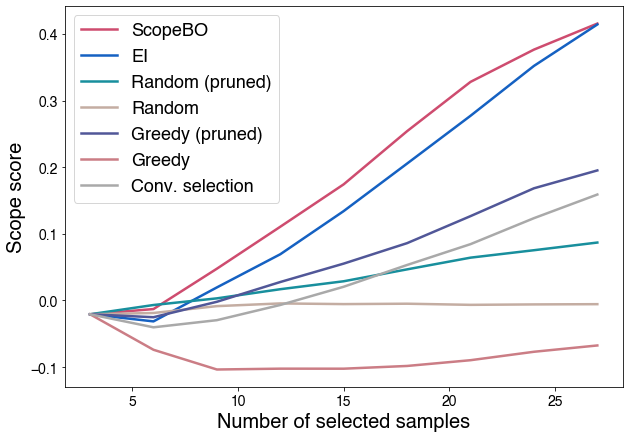

Average_objective:


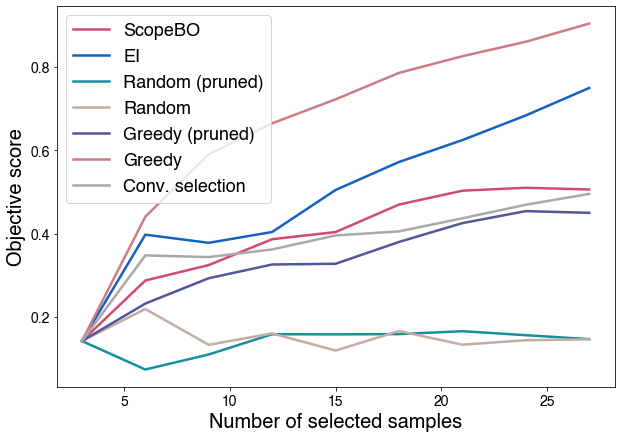

Vendi score:


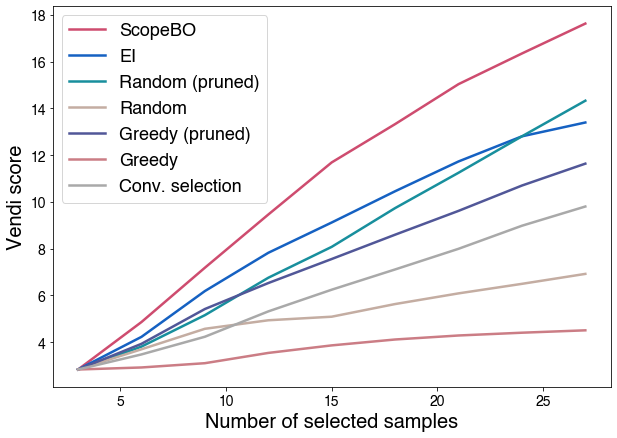

In [10]:
for type_results in ["Scope","Objective","Vendi"]:
    dfs = {}
    for acq in ["EI","Random","Greedy","Conv. selection"]:
        if acq == "EI":
            acq_label = "balanced"
        elif acq == "Conv. selection":
            acq_label = "human-like-acq"
        else:
            acq_label = acq.lower()
        for pruning in [True,False]:
            if pruning:
                pruning_label = "_pruning"
                pruning_flag = "with"
            else:
                pruning_label = "_no-pruning"
                pruning_flag = "without"
            if acq == "Conv. selection":
                pruning_label = ""
            dfs_progress = Benchmark().progress_plot(budget=27, type_results= type_results,
                                    name_results=f"./Results_Data/scope_{acq_label}{pruning_label}",show_plot=False,
                                    objective_mode={"yield":"max","cost":"min"},
                                    bounds=bounds)
            dfs[acq+pruning_label] = dfs_progress["means"]
    df_combined = pd.concat(dfs,axis=1)
    df_combined.columns = [multiindex[0] for multiindex in df_combined.columns]
    df_combined.rename(columns={"EI_pruning":"ScopeBO"},inplace=True)
    df_combined = df_combined[["ScopeBO"] + [col for col in df_combined.columns if col != "ScopeBO"]]
    label_dict = {col: col for col in df_combined.columns}
    for key,val in label_dict.items():
        if "_no-pruning" in val:
            label_dict[key] = val.split("_")[0]
        elif "pruning" in val:
            label_dict[key] = val.split("_")[0] + " (pruned)"
    df_combined.rename(columns=label_dict,inplace=True)
    if type_results == "Objective":
        print("Average_objective:")
    else:
        print(f"{type_results} score:")
    # Plot.
    plt.figure(figsize=(10,7))
    for j,col in enumerate(df_combined.columns):
        style = '-' if j <= 6 else '--' if j <= 13 else ':'
        plotting = df_combined[col][df_combined[col].notna()]
        plt.plot(plotting.index, plotting.values, label = col, color=all_colors[j], linestyle=style, linewidth=2.5)
    plt.xlabel('Number of selected samples',fontsize=20)
    plt.ylabel(f"{type_results} score",fontsize=20)
    plt.legend(fontsize=18)
    plt.show()

ScopeBO and EI give essentially the same scope score, but the Vendi score using ScopeBO is much higher and the average objective score (average of yield and cost) is still above average of the dataset (0.473). Greedy-pruning has a surprisingly low average objective (typically significantly higher than ScopeBO).

### Statistical testing

To test for statistically significant differences between the selection methods, we carried out a Friedman test for each dataset to test if the scope scores are similar between the methods.

Note that we can not carry out these tests for clustering-based methods as they are deterministic and do not provide a distribution of scope score results.

In [11]:
# read in the data
scope_scores = None
vendi_scores = None
av_yields = None
av_costs = None
renaming = {"Greedy_no-pruning":"Greedy",
            "Greedy_pruning":"Greedy (pruned)",
            "EI_no-pruning":"EI",
            "EI_pruning":"ScopeBO",
            "Random_no-pruning":"Random",
            "Random_pruning":"Random (pruned)",
            "Conv. selection":"Conv. selection"}

for score_type in ["scope","vendi","yield","cost"]:
    scores = pd.DataFrame(np.nan, index=list(renaming.values()), columns=list(range(20)))
    for acq in ["EI","Random","Greedy","Conv. selection"]:
        if acq.lower() == "ei":
            acq_label = "balanced"
        elif acq.lower() == "conv. selection":
            acq_label = "human-like-acq"
        else:
            acq_label = acq.lower()
        for pruning in [True,False]:
            if acq.lower() == "conv. selection" and pruning:
                continue  # only read the human-like acq once (no pruning distinction)
            if pruning:
                pruning_label = "_pruning"
            else:
                pruning_label = "_no-pruning"
            if acq.lower() == "conv. selection":
                pruning_label = ""
            _, dict_data = Benchmark().get_metric_overview(bounds = bounds, budget = 27, objective_mode={"yield":"max","cost":"min"},
                                                name_results=f"./Results_Data/scope_{acq_label}{pruning_label}", 
                                                type_results=score_type)
            for seed_dict in dict_data.values():
                for seed, df in seed_dict.items():
                    scores.loc[renaming[acq+pruning_label], seed] = df.loc[8,score_type]
    if score_type == "scope":
        scope_scores = scores.copy()
    elif score_type == "vendi":
        vendi_scores = scores.copy()
    elif score_type == "yield":
        av_yields = scores.copy()
    elif score_type == "cost":
        av_costs = scores.copy()

In [12]:
from scipy.stats import friedmanchisquare
print("Friedman test results for Scope scores:\n")
res = friedmanchisquare(*scope_scores.values)
print("Friedman statistic:", res.statistic, "\np-value:", res.pvalue)

Friedman test results for Scope scores:

Friedman statistic: 103.41428571428571 
p-value: 4.8611434691034506e-20


In [13]:
print("Friedman test results for Vendi scores:\n")
res = friedmanchisquare(*vendi_scores.values)
print("Friedman statistic:", res.statistic, "\np-value:", res.pvalue)

Friedman test results for Vendi scores:

Friedman statistic: 113.63571428571424 
p-value: 3.5281094782554757e-22


In [14]:
print("Friedman test results for average yields:\n")
res = friedmanchisquare(*av_yields.values)
print("Friedman statistic:", res.statistic, "\np-value:", res.pvalue)

Friedman test results for average yields:

Friedman statistic: 61.37142857142862 
p-value: 2.3686068232126095e-11


In [15]:
print("Friedman test results for average costs:\n")
res = friedmanchisquare(*av_costs.values)
print("Friedman statistic:", res.statistic, "\np-value:", res.pvalue)

Friedman test results for average costs:

Friedman statistic: 57.214285714285666 
p-value: 1.6532322735835616e-10


Differences between the selection methods were found (null hypothesis rejected as p < 5%) for all metrics. Thus, we continue with two-sided Wilcoxon tests between ScopeBO and the other methods, controlling for the initiation seed, while correcting for multiple comparisons with the Holm-Bonferroni method.

In [16]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def wilcoxon_tests(df):
    """
    Function for performing pairwise Wilcoxon signed-rank tests 
    comparing ScopeBO to each other method, with Holm-Bonferroni correction.
    """
    methods = df.index.tolist()
    reference = methods[3]  # ScopeBo is the 4th method in index of the df

    comparisons = []
    p_values = []

    for method in methods:
        if method == reference:
            continue
        
        # Two-sided Wilcoxon of ScopeBo versus the other method
        stat, p = wilcoxon(
            df.loc[reference],
            df.loc[method],
            alternative= "two-sided"
        )
        
        comparisons.append(method)
        p_values.append(p)

    # Holm-Bonferroni correction
    reject, pvals_corrected, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method='holm'
    )
    print(comparisons)
    results = pd.DataFrame({
        "Comparison": comparisons,
        "Corrected p-value": pvals_corrected,
        "ScopeBO higher?": [np.mean(df.loc[reference].values) > np.mean(df.loc[comp].mean()) for comp in comparisons],
        "Different?": reject,
    })

    print(f"Reference method: {reference}")
    display(results)

In [17]:
print("Two-sided Wilcoxon signed-rank tests comparing ScopeBO to other methods (Scope score):\n")
wilcoxon_tests(scope_scores)

Two-sided Wilcoxon signed-rank tests comparing ScopeBO to other methods (Scope score):

['Greedy', 'Greedy (pruned)', 'EI', 'Random', 'Random (pruned)', 'Conv. selection']
Reference method: ScopeBO


,Comparison,Corrected p-value,ScopeBO higher?,Different?
0,Greedy,0.000011,True,True
1,Greedy (pruned),0.000011,True,True
2,EI,0.956329,True,False
3,Random,0.000011,True,True
4,Random (pruned),0.000011,True,True
5,Conv. selection,0.000011,True,True


In [18]:
print("Two-sided Wilcoxon signed-rank tests comparing ScopeBO to other methods (Vendi score):\n")
wilcoxon_tests(vendi_scores)

Two-sided Wilcoxon signed-rank tests comparing ScopeBO to other methods (Vendi score):

['Greedy', 'Greedy (pruned)', 'EI', 'Random', 'Random (pruned)', 'Conv. selection']
Reference method: ScopeBO


,Comparison,Corrected p-value,ScopeBO higher?,Different?
0,Greedy,0.000011,True,True
1,Greedy (pruned),0.000011,True,True
2,EI,0.000011,True,True
3,Random,0.000011,True,True
4,Random (pruned),0.000011,True,True
5,Conv. selection,0.000011,True,True


In [19]:
print("Two-sided Wilcoxon signed-rank tests comparing ScopeBO to other methods (average yields):\n")
wilcoxon_tests(av_yields)

Two-sided Wilcoxon signed-rank tests comparing ScopeBO to other methods (average yields):

['Greedy', 'Greedy (pruned)', 'EI', 'Random', 'Random (pruned)', 'Conv. selection']
Reference method: ScopeBO


,Comparison,Corrected p-value,ScopeBO higher?,Different?
0,Greedy,0.019440,False,True
1,Greedy (pruned),0.659966,True,False
2,EI,0.000019,False,True
3,Random,0.028307,True,True
4,Random (pruned),0.000011,True,True
5,Conv. selection,0.659966,True,False


In [20]:
print("Two-sided Wilcoxon signed-rank tests comparing ScopeBO to other methods (average costs):\n")
wilcoxon_tests(av_costs)

print("\nNote that this is a minimization task so that higher means worse.")

Two-sided Wilcoxon signed-rank tests comparing ScopeBO to other methods (average costs):

['Greedy', 'Greedy (pruned)', 'EI', 'Random', 'Random (pruned)', 'Conv. selection']
Reference method: ScopeBO


,Comparison,Corrected p-value,ScopeBO higher?,Different?
0,Greedy,0.010849,True,True
1,Greedy (pruned),0.522198,False,False
2,EI,0.522198,True,False
3,Random,0.001974,False,True
4,Random (pruned),0.000023,False,True
5,Conv. selection,0.428719,True,False



Note that this is a minimization task so that higher means worse.


# Also run Doyle clustering for comparison

Only the Doyle clustering algorithm can be carried out as the Glorius one takes SMILES strings as input that are not available for this reaction optimization dataset.

In [21]:
# A scaled dataframe containing the features was already generated in the beginning of this notebook. Check how many dimensions there are.
print(f"There are {len(df_data.columns)} dimensions in the dataset.")

There are 530 dimensions in the dataset.


In [22]:
# define the dimensionalities of the reduced representation to study
dims = [530, 500, 450, 400, 350, 300, 250, 200, 150, 100, 50, 25, 20, 15, 10, 5, 2]

# function to calculate silhouette scores
def silhouette_scores_hierarchical(data, n_cls_list):
    """helper function to compute a silhouette score for hierarchical clustering using Ward linkage"""
    z = linkage(data, method='ward')
    result = pd.Series(index=n_cls_list, dtype=float)
    for n_cls in n_cls_list:
        cls = fcluster(z, n_cls, criterion='maxclust')
        result.loc[n_cls] = silhouette_score(data, cls)
    return result

# dictionary to store data at different levels of dimensionality reduction
n_neighbors = int(np.sqrt(df_data.shape[1]))
dfs = {}
for dim in dims:
    key = f"umap{dim}"
    dfs[key] = pd.DataFrame(UMAP(n_components=dim, n_neighbors=n_neighbors,
                                    random_state=0).fit_transform(df_data),index=df_data.index)

Graph is not fully connected, spectral embedding may not work as expected.
Graph is not fully connected, spectral embedding may not work as expected.
Graph is not fully connected, spectral embedding may not work as expected.


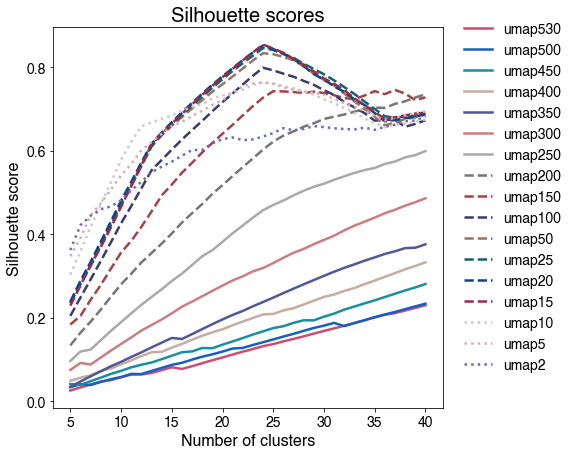

,Representation,Nr_clusters,Silh_score,Representation (min 15 clusters),Nr_clusters (min 15 clusters),Silh_score (min 15 clusters)
Results,umap15,24.0,0.854313,umap15,24.0,0.854313


In [23]:
# range of scope sizes to be studied
N_CLS_list = list(range(5,41))
# min number of clusters for the scope
min_clust = 15
# df to save the results of the silhouette score analysis
best_silh_scores = pd.DataFrame(np.nan,index=["Results"],columns=["Representation","Nr_clusters", "Silh_score",
                                                               f"Representation (min {min_clust} clusters)", 
                                                               f"Nr_clusters (min {min_clust} clusters)",
                                                               f"Silh_score (min {min_clust} clusters)"])

plt.figure(figsize=(7,7))
plt.title("Silhouette scores")
plt.xlabel("Number of clusters",fontsize=16)
plt.ylabel("Silhouette score",fontsize=16)

# populate silhouette scores for all number of clusters and all dimensionality reductions
silh_scores = pd.DataFrame(index=N_CLS_list)
for key, value in dfs.items():
    silh_scores[key] = silhouette_scores_hierarchical(value, N_CLS_list)
for j,col in enumerate(silh_scores.columns):
    style = '-' if j <= 6 else '--' if j <= 13 else ':'
    plotting = silh_scores[col][silh_scores[col].notna()]
    plt.plot(plotting.index, plotting.values, label = col, color=all_colors[j], linestyle=style, linewidth=2.5)

# record the representation that gives the best silhouette score
max_position = silh_scores.stack().idxmax()
best_silh_scores.loc["Results","Representation"] = max_position[1]
best_silh_scores.loc["Results","Nr_clusters"] = int(max_position[0])
best_silh_scores.loc["Results","Silh_score"] = silh_scores.max().max()
silh_scores_pruned = silh_scores.loc[silh_scores.index >= min_clust]
max_position_pruned = silh_scores_pruned.stack().idxmax()
best_silh_scores.loc["Results",f"Representation (min {min_clust} clusters)"] = max_position_pruned[1]
best_silh_scores.loc["Results",f"Nr_clusters (min {min_clust} clusters)"] = int(max_position_pruned[0])
best_silh_scores.loc["Results",f"Silh_score (min {min_clust} clusters)"] = silh_scores_pruned.max().max()
plt.legend(loc='center left',
           frameon =False,
           bbox_to_anchor=(1.02, 0.555))
plt.show()

best_silh_scores

In [24]:
embedding = best_silh_scores.loc["Results",f"Representation (min {min_clust} clusters)"]
nr_clusters = best_silh_scores.loc["Results",f"Nr_clusters (min {min_clust} clusters)"]

# Clustering
z = hierarchy.linkage(dfs[embedding],method ="ward",metric="euclidean")
clusters = hierarchy.fcluster(z,nr_clusters,criterion="maxclust")

# Assign to samples
df_data["clusters"] = clusters
df_umap["clusters"] = clusters

Visualization of the clusters:


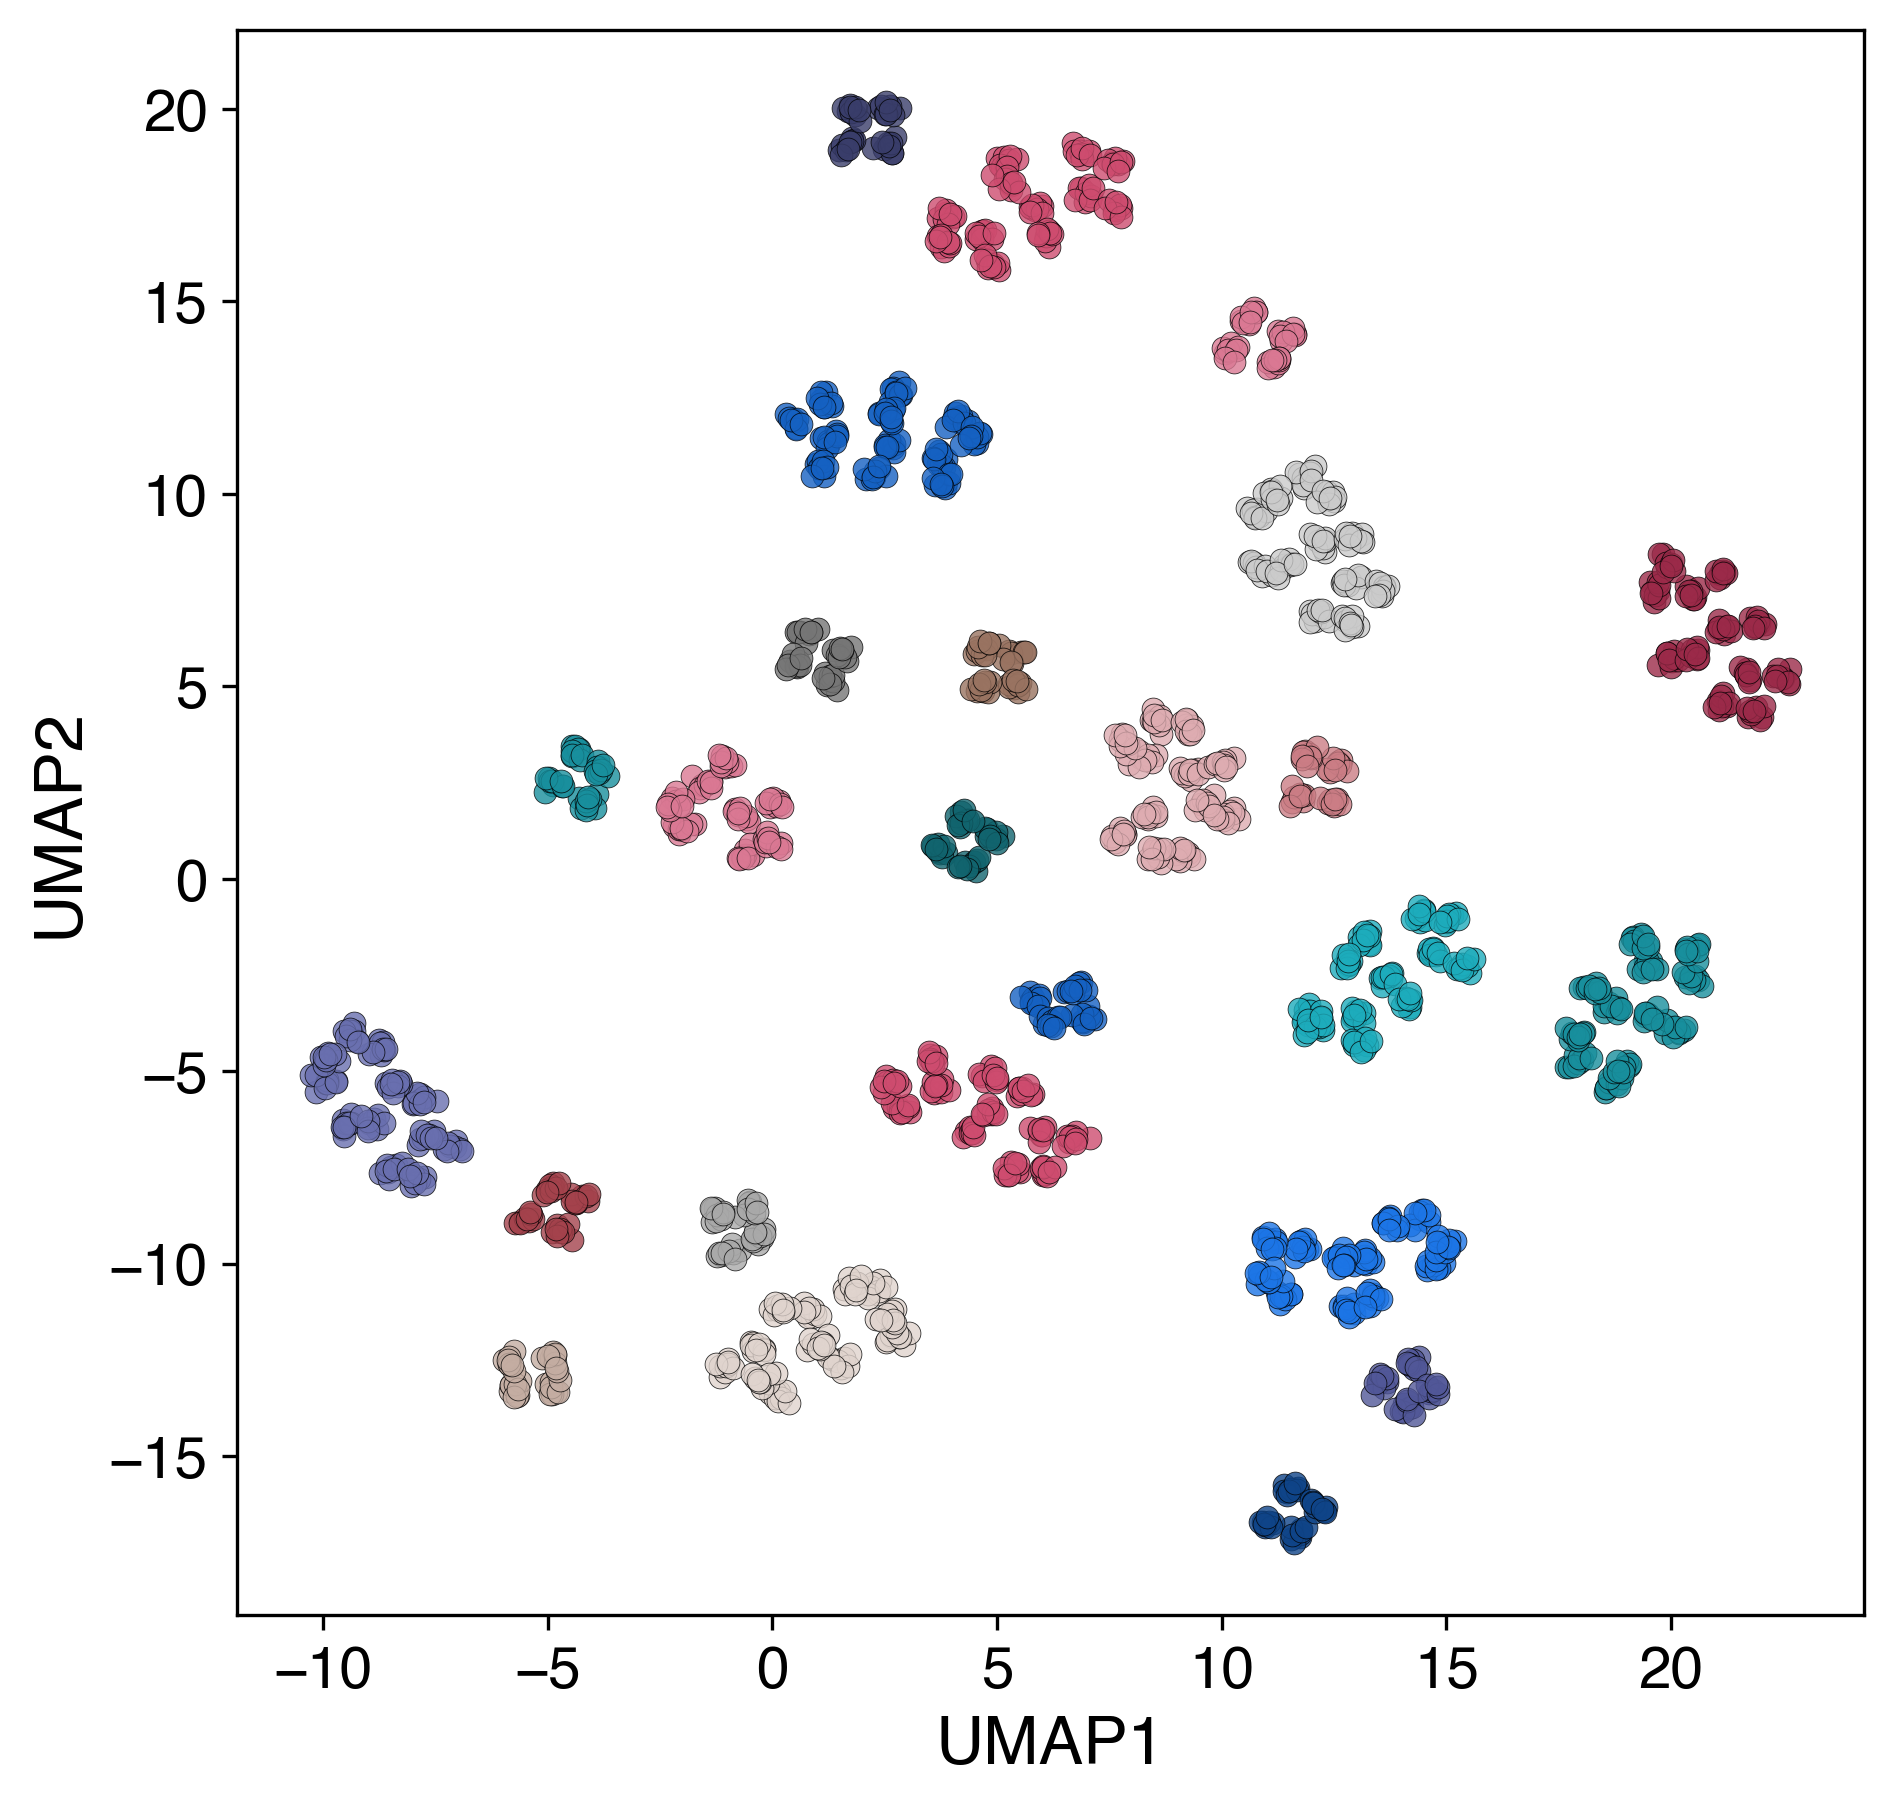

Please note that some colors only differ in the shade or occur
for two different clusters due to the large number of clusters.


In [25]:
# draw the clusters
print("Visualization of the clusters:")

# making sure there are enough colors
all_colors = all_colors * 4

plt.figure(figsize=(7,7),dpi=300)
plt.xlabel("UMAP1",fontsize=16)
plt.ylabel("UMAP2",fontsize=16)

for cluster_id in sorted(df_umap['clusters'].unique()):
    color_id = cluster_id-1  # colors are zero-index, but clusters one-indexed
    cluster_data = df_umap[df_umap['clusters'] == cluster_id]
    plt.scatter(
        cluster_data['UMAP1'], cluster_data['UMAP2'],
        color=all_colors[color_id],
        label=f'Cluster {cluster_id}',
        s=30, alpha=0.8, edgecolor='k', linewidth=0.2
    )
plt.show()
print("Please note that some colors only differ in the shade or occur\nfor "\
      "two different clusters due to the large number of clusters.")

In [26]:
# function to calculate the scope score
def calculate_scope_score(av_yield,av_cost,Vendi_score,bounds):
    scaled_yield = (av_yield - bounds["yield"][1])/(bounds["yield"][0] - bounds["yield"][1])
    scaled_cost = (av_cost - bounds["cost"][1])/(bounds["cost"][0] - bounds["cost"][1])
    scaled_cost = 1- scaled_cost  # inverted because it is a minimization task
    scaled_obj = (scaled_yield + scaled_cost)/2
    scaled_Vendi = (Vendi_score - bounds["vendi"][1])/(bounds["vendi"][0] - bounds["vendi"][1])

    return scaled_obj * scaled_Vendi, scaled_obj

In [27]:
# calculate the center-most point of each cluster and the Vendi score for the resulting samples
scope_results = pd.DataFrame(np.nan,index=["Results"],columns=["Average yield","Average cost","Average mean norm. objective","Vendi score","Scope score"])

cluster_yields = [] # list to save the yields
cluster_costs = [] # list to save the costs
df_vendi = df_labelled.copy(deep=True)
df_vendi["obj_scaled"] = "PENDING"  # reset the rate data so that only the selected points will have a rate
for cluster in range(max(df_data["clusters"].unique())):  # loop through all clusters
    cluster = cluster+1  # +1 because the range object is 0-indexed whereas the cluster are 1-indexed
    df_cluster = df_data.loc[df_data["clusters"]== cluster]  # look at the points in the current cluster
    df_cluster = df_cluster.drop(columns=["clusters"])  # drop the cluster column to only keep the features (df_clustering did not contain the rate data)
    centroid = df_cluster.mean().values  # this is the center of the cluster
    distances = cdist(df_cluster,[centroid],metric="cityblock").flatten()  # calculate the distances to the center
    df_cluster["distances"] = distances

    centermost_point = df_cluster[df_cluster["distances"] == df_cluster["distances"].min()].index.item()  # get the center-most point
    yield_clusterpoint = df_labelled.at[centermost_point,"yield"]  # get the rate data for the center-most point
    cost_clusterpoint = df_labelled.at[centermost_point,"cost"]  # get the rate data for the center-most point

    df_vendi.loc[centermost_point,"obj_scaled"] = "1"  # put a label for the vendi score calculation (value is not important)
    cluster_yields.append(yield_clusterpoint)  # save the point
    cluster_costs.append(cost_clusterpoint)  # save the other objective
av_yield = sum(cluster_yields)/len(cluster_yields)
av_cost = sum(cluster_costs)/len(cluster_costs)

scope_results.loc["Results","Average yield"] = av_yield
scope_results.loc["Results","Average cost"] = av_cost
df_vendi.to_csv(wdir.joinpath("df_clustering_vendi.csv"),index=True,header=True)  # save the file (as the Vendi score calculation needs a file as input)
Vendi_score = ScopeBO().get_vendi_score(objectives=["yield","cost","obj_scaled"],directory=".",filename="df_clustering_vendi.csv")  # calculate the vendi score
scope_results.loc["Results","Vendi score"] = Vendi_score
scope_score, scaled_obj = calculate_scope_score(av_yield,av_cost,Vendi_score,bounds)
scope_results.loc["Results","Scope score"] = scope_score
scope_results.loc["Results","Average mean norm. objective"] = scaled_obj

In [28]:
# make an additional column in the labelled dataset with the scaled mean objective
min_yield = df_labelled["yield"].min()
max_yield = df_labelled["yield"].max()
min_cost = df_labelled["cost"].min()
max_cost = df_labelled["cost"].max()
df_labelled["yield_scaled"] = (df_labelled["yield"] - min_yield)/(max_yield - min_yield)
df_labelled["cost_scaled"] = 1 - (df_labelled["cost"] - min_cost)/(max_cost - min_cost)  # minimization task
df_labelled["obj_scaled"] = (df_labelled["yield_scaled"] + df_labelled["cost_scaled"])/2

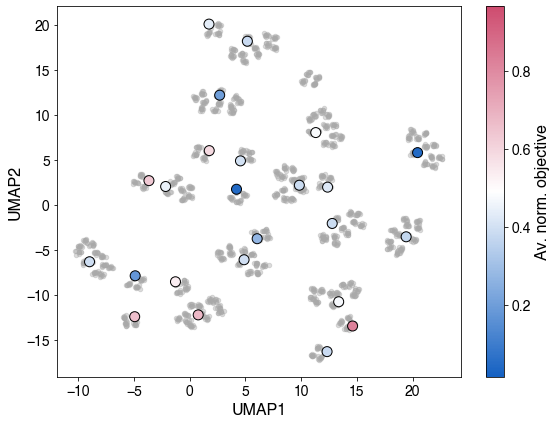

Scope results:


,Average yield,Average cost,Average mean norm. objective,Vendi score,Scope score
Results,18.664167,0.183767,-0.222388,15.706841,-0.155744


In [29]:
plt.figure(figsize=(8,6))
plt.xlabel("UMAP1",fontsize=16)
plt.ylabel("UMAP2",fontsize=16)

# only keep the objective label for evaluated points
df_umap["obj_scaled"] = df_labelled["obj_scaled"]

for idx in df_vendi.index:
    if df_vendi.loc[idx,"obj_scaled"] == "PENDING":
        df_umap.loc[idx,"obj_scaled"] = "PENDING"

# Separate numeric and non-numeric (e.g., "PENDING") entries
df_numeric = df_umap[pd.to_numeric(df_umap['obj_scaled'], errors='coerce').notna()].copy()
df_numeric['obj_scaled'] = df_numeric['obj_scaled'].astype(float)
df_pending = df_umap[pd.to_numeric(df_umap['obj_scaled'], errors='coerce').isna()]

# Define colormap and normalization
vmin = df_labelled['obj_scaled'].min()
vmax = df_labelled['obj_scaled'].max()
norm = plt.Normalize(vmin, vmax)
cmap = sns.color_palette("Doyle_cont", as_cmap=True)

# Plot non-numeric entries ("PENDING")
plt.scatter(df_pending["UMAP1"], df_pending["UMAP2"], color=all_colors[6], s=20, alpha=0.4, label="PENDING")
# Plot numeric entries
scatter_numeric = plt.scatter(df_numeric["UMAP1"],df_numeric["UMAP2"],c=df_numeric["obj_scaled"],cmap=cmap,norm=norm,s=100,alpha=1,edgecolor='k',linewidth=1)
# Add colorbar
cbar = plt.colorbar(scatter_numeric)
cbar.set_label("Av. norm. objective")

plt.tight_layout()
plt.show()
print("Scope results:")
scope_results

In [30]:
print("Normalization bounds for comparison:")
pd.DataFrame.from_dict(bounds)

Normalization bounds for comparison:


,yield,vendi,cost
0,46.070487,20.342509,0.148498
1,18.418487,4.873579,0.070757


In [31]:
print("Average results for ScopeBO:")
_,dfs_raw_data = Benchmark().get_metric_overview(budget=27, type_results= "scope",
                        name_results=f"./Results_Data/scope_balanced_pruning",
                        objective_mode={"yield":"max","cost":"min"},
                        bounds={"yield":yield_bounds,"cost":cost_bounds,"vendi":vendi_bounds})
df_scopebo = pd.DataFrame(np.mean(np.stack(list(dfs_raw_data["b3_V13"].values())),axis=0),columns=dfs_raw_data["b3_V13"][0].columns)
# make an additional column with the scaled mean objective
df_scopebo["yield_scaled"] = (df_scopebo["yield"] - bounds["yield"][1])/(bounds["yield"][0] - bounds["yield"][1])
df_scopebo["cost_scaled"] = 1 - (df_scopebo["cost"] - bounds["cost"][1])/(bounds["cost"][0] - bounds["cost"][1])  # minimization task
df_scopebo["obj_scaled"] = (df_scopebo["yield_scaled"] + df_scopebo["cost_scaled"])/2
df_scopebo.drop(columns=["yield_scaled","cost_scaled"]).iloc[-1]

Average results for ScopeBO:


vendi         17.631531
yield         29.403037
cost           0.100766
scope          0.415704
obj_scaled     0.505615
Name: 8, dtype: float64

### Benchmark comparisons

Collect the data

In [32]:
acq_fct = ["EI","Random","Greedy","Conv. selection"]
pruning_opt = [False,True]
datasets = ["high","medium","low"]

map_data = {}
std_data = {}
for acq in acq_fct:
    if acq.lower() == "ei":
        acq_label = "balanced"
    elif acq == "Conv. selection":
        acq_label =  "human-like-acq"
    else:
        acq_label = acq.lower()
    for pruning in [True,False]:
        if pruning:
            pruning_label = "_pruning"
        else:
            pruning_label = "_no-pruning"
        if acq == "Conv. selection":
            pruning_label = ""
        run_results = []
        std_results = []
        for type_results in ["Objective","Vendi","Scope"]:
            dfs_scaled,_ = Benchmark.get_metric_overview(budget=27,type_results=type_results,
                                            name_results=f"Results_Data/scope_{acq_label}{pruning_label}",
                                            scope_method="product", objective_mode={"yield": "max", "cost":"min"},objective_weights=None,
                                            bounds = bounds, directory=".")
            run_results.append(dfs_scaled["means"].iloc[-1,0])  # save the last mean which is the result at the end of the scope
            std_results.append(dfs_scaled["stdev"].iloc[-1,0])  # same for the standard deviation of the result
        map_data[f"{acq}{pruning_label}"] = run_results
        std_data[f"{acq}{pruning_label}"] = std_results
map_df = pd.DataFrame.from_dict(map_data)
std_df = pd.DataFrame.from_dict(std_data)

# add clustering data
# col 2 is averaged objectives; 3 is Vendi score; 4 is scope score
map_df["Doyle_clustering"] = [scope_results.iloc[0,2],scope_results.iloc[0,3],scope_results.iloc[0,4]]
std_df["Doyle_clustering"] = [0,0,0]  # no std as only one deterministic run

Note: in map_df and std_df, the first row is the mean normalized objective value, the second row is the Vendi score, and the third row is the scope score.

In [33]:
new_index = ["Average norm. objective", "Vendi score", "Scope score"]
new_cols = ["ScopeBo", "EI", "Random (pruned)", "Random", "Greedy (pruned)", 
            "Greedy", "Conv. selection", "Doyle clustering"]
map_df.index = new_index
map_df.columns = new_cols
map_df.T

,Average norm. objective,Vendi score,Scope score
ScopeBo,0.505615,17.631531,0.415704
EI,0.748951,13.398105,0.414370
Random (pruned),0.146996,14.330619,0.086984
Random,0.146524,6.919141,-0.005537
Greedy (pruned),0.449673,11.637085,0.195258
Greedy,0.903236,4.503960,-0.067518
Conv. selection,0.495064,9.802711,0.159068
Doyle clustering,-0.222388,15.706841,-0.155744


In [34]:
new_index = ["Average norm. objective", "Vendi score", "Scope score"]
new_cols = ["ScopeBo", "EI", "Random (pruned)", "Random", "Greedy (pruned)", 
            "Greedy", "Conv. selection", "Doyle clustering"]
std_df.index = new_index
std_df.columns = new_cols
std_df.applymap(lambda x: round(x,3)).T

,Average norm. objective,Vendi score,Scope score
ScopeBo,0.118,0.541,0.092
EI,0.134,0.845,0.094
Random (pruned),0.145,1.008,0.092
Random,0.331,2.045,0.028
Greedy (pruned),0.231,0.983,0.103
Greedy,0.431,2.003,0.075
Conv. selection,0.207,0.896,0.077
Doyle clustering,0.000,0.000,0.000


In [35]:
full_av_yield = df_labelled["yield"].mean()
print("Average yield for the full dataset:", full_av_yield)
full_av_cost = df_labelled["cost"].mean()
print("Average cost for the full dataset:", full_av_cost)

scaled_yield = full_av_yield/100  # yield is on 0 to 100 scale
min_cost, max_cost = df_labelled["cost"].min(), df_labelled["cost"].max()
scaled_cost = 1 - (full_av_cost - min_cost) / (max_cost - min_cost)  # minimization task
full_av_obj = 0.5 * (scaled_yield + scaled_cost)
print("Average mean normalized objective for the full dataset:", full_av_obj)

Average yield for the full dataset: 19.374704861111113
Average cost for the full dataset: 0.1350685681087963
Average mean normalized objective for the full dataset: 0.47318621637730557


In [36]:
full_Vendi = ScopeBO().get_vendi_score(filename=f"./arylation_labelled_data.csv",
                          objectives = ['yield','cost'])
print("Vendi score of the full dataset:", full_Vendi)

Vendi score of the full dataset: 39.770795371243366


Visualize the results

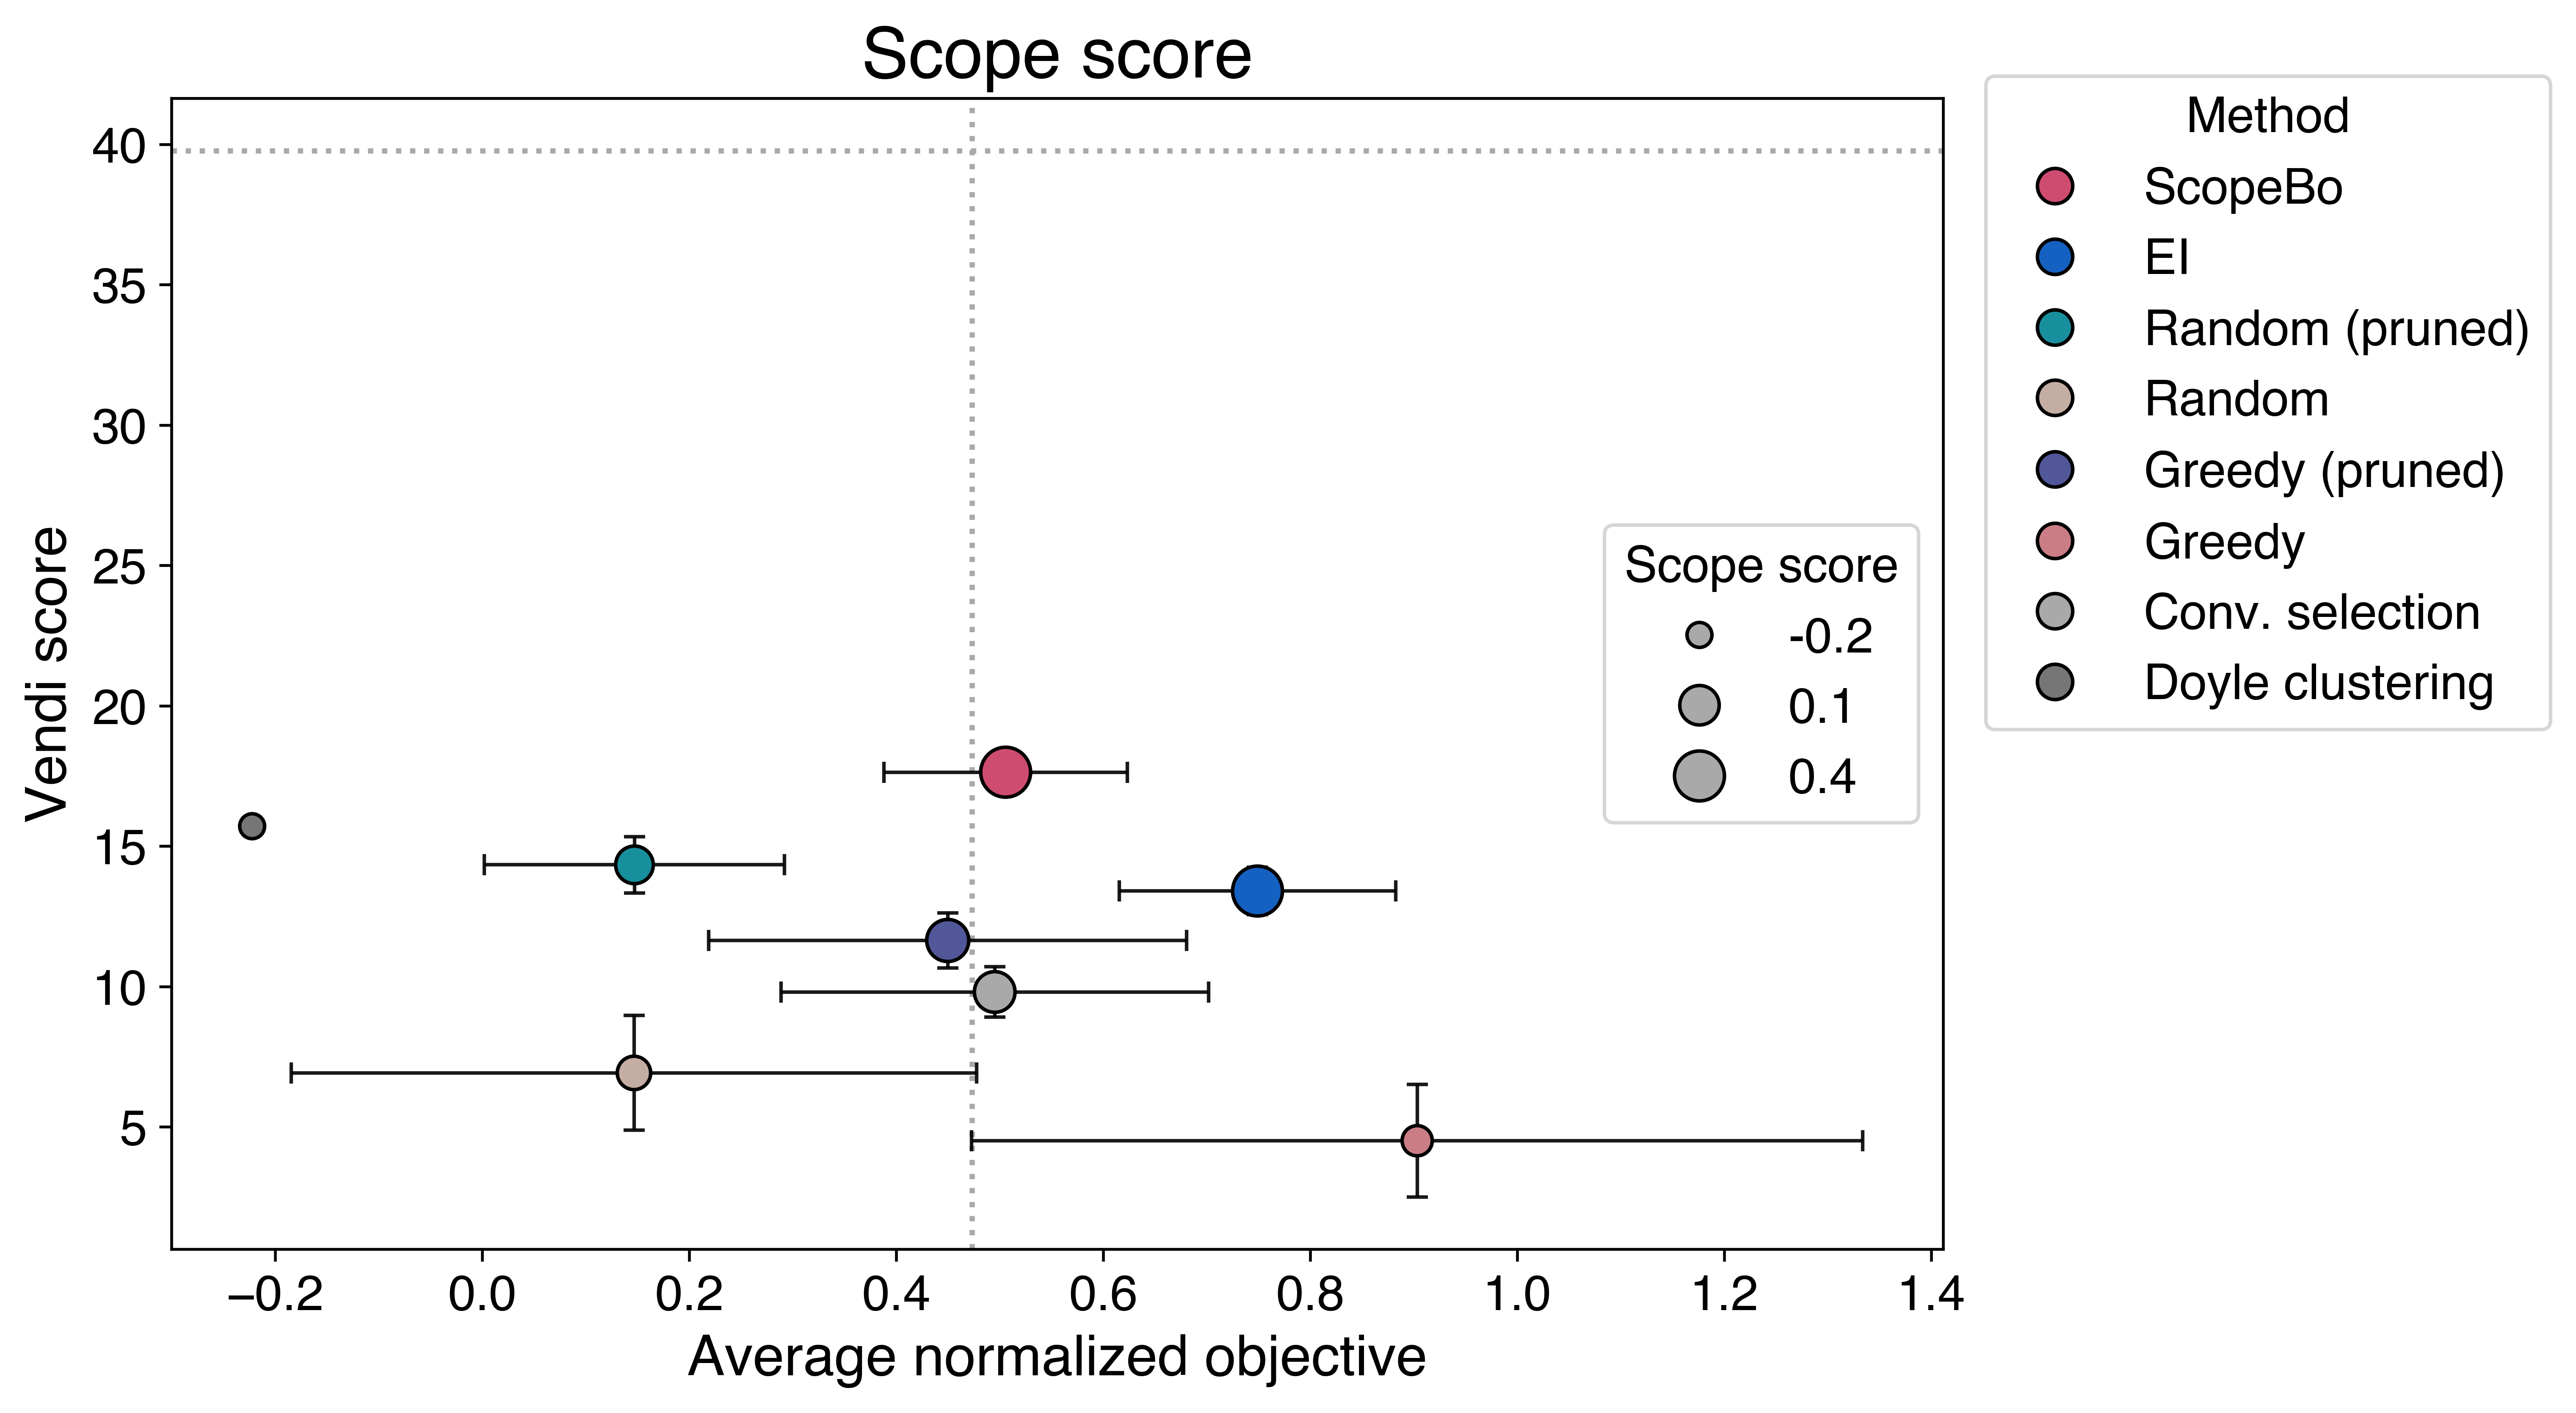

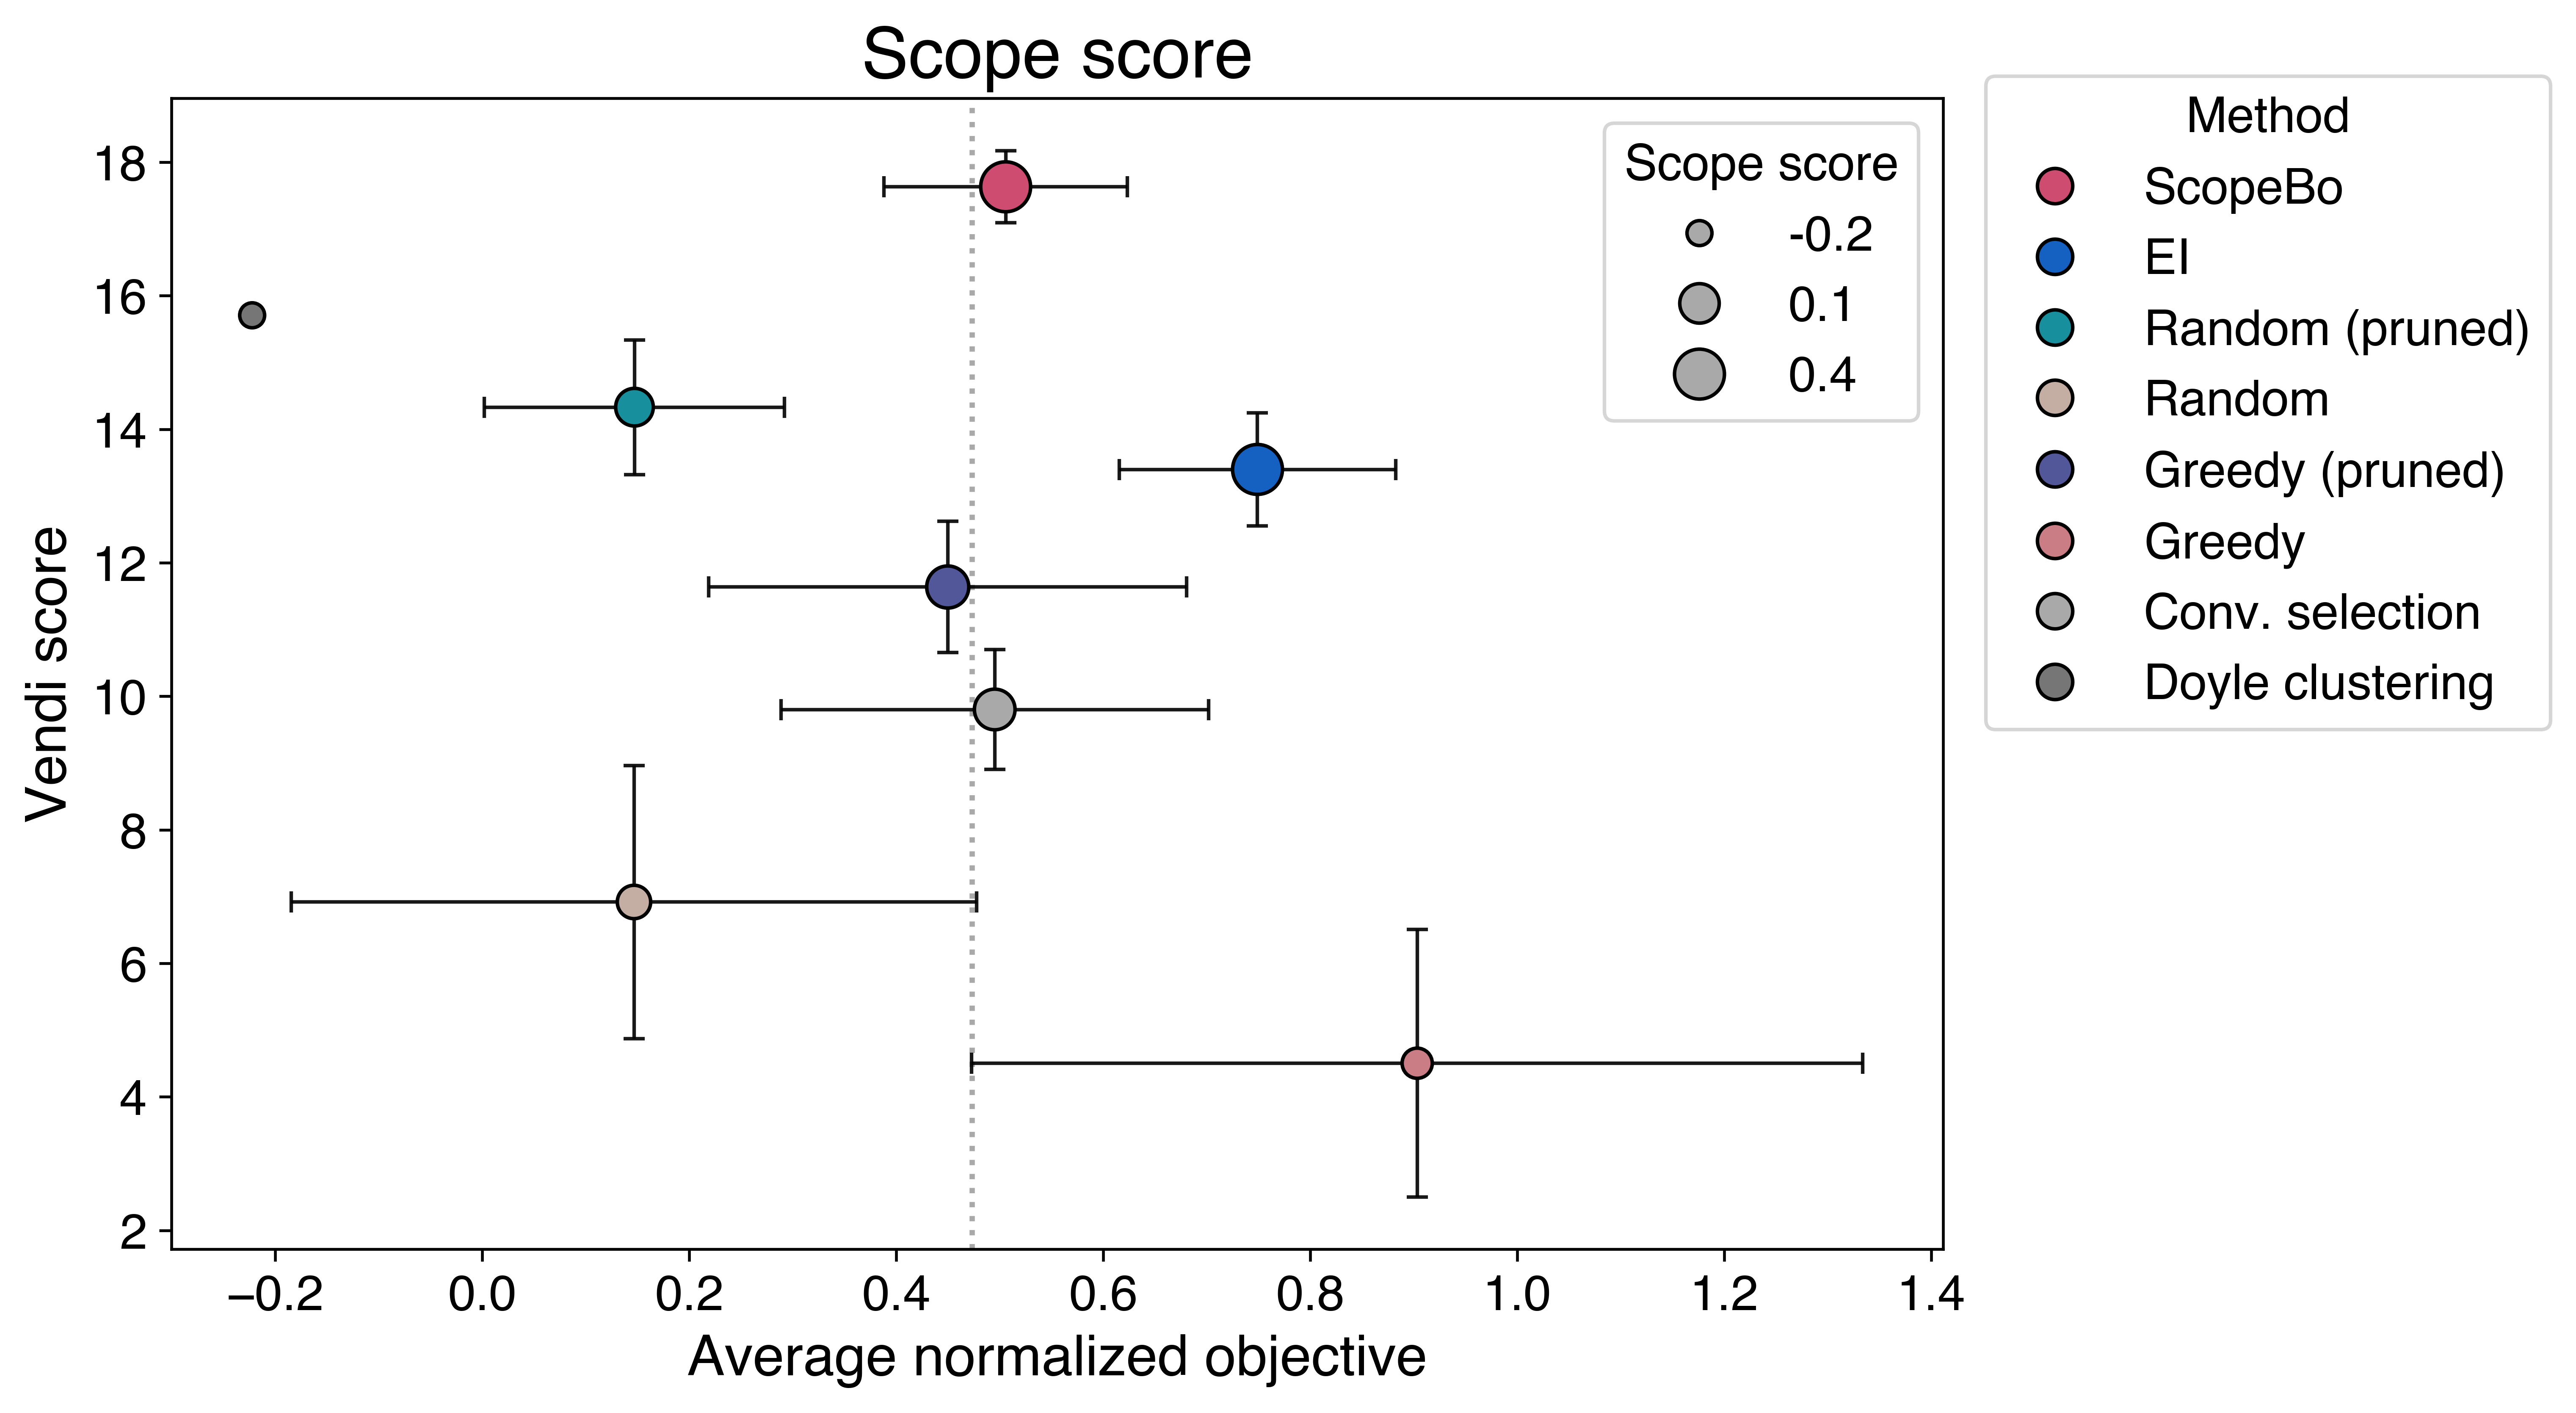

,Av. norm. objective,Vendi score,Scope score
ScopeBo,0.506,17.632,0.416
EI,0.749,13.398,0.414
Random (pruned),0.147,14.331,0.087
Random,0.147,6.919,-0.006
Greedy (pruned),0.450,11.637,0.195
Greedy,0.903,4.504,-0.068
Conv. selection,0.495,9.803,0.159
Doyle clustering,-0.222,15.707,-0.156


In [38]:
# Plot the results
x = map_df.iloc[0]
y = map_df.iloc[1]
xerr = std_df.iloc[0]
yerr = std_df.iloc[1]
raw_size_data = map_df.iloc[2]

size_min, size_max = 50, 200
data_min, data_max= raw_size_data.min(), raw_size_data.max()
sizes = size_min + (raw_size_data - data_min) * (size_max - size_min) / (data_max - data_min)

# simplify the labels for the legend
labels = map_df.columns
labels = list(labels)
for i,val in enumerate(labels):
    if val == "EI_pruning":
        labels[i] = "ScopeBO"
    elif "no-pruning" in val:
        labels[i] = val.split("_")[0]
    elif "_pruning" in val:
        labels[i] = val.split("_")[0] + " (pruned)"
map_df.columns = labels


color_map = {label: all_colors[i] for i, label in enumerate(labels)}
colors = [color_map[label] for label in labels]
alpha_val = 1

def plot_results(show_full_Vendi = True):
    plt.figure(figsize=(9,6),dpi=600)
    plt.title(f"Performance map")
    plt.scatter(x, y, s=sizes, alpha=alpha_val, c = colors, edgecolors="k", zorder = 2)
    # Add error bars
    plt.errorbar(
        x, y,
        xerr=xerr,
        yerr=yerr,
        fmt='none',
        ecolor='black',
        elinewidth=1,
        capsize=3,
        alpha=0.9,
        zorder=1
    )

    # add lines for the results for the full dataset
    # Vertical line for the dataset average objective
    plt.axvline(x=full_av_obj, color=all_colors[6], linestyle=':', linewidth=1.5, zorder=0)
    # Horizontal line for the Vendi score of the full dataset
    if show_full_Vendi:
        plt.axhline(y=full_Vendi, color=all_colors[6], linestyle=':', linewidth=1.5, zorder=0)

    plt.xlabel('Average normalized objective')
    plt.ylabel('Vendi score')
    plt.title('Scope score')

    # legend for the methods
    color_legend = [
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=label,
            markerfacecolor=color_map[label],
            alpha=alpha_val,
            markeredgecolor='k',
            markersize=10
        )
        for label in labels
    ]

    # legend for scope score
    # Choose representative raw size values
    size_legend_values = np.linspace(raw_size_data.min(), raw_size_data.max(), 3)
    size_legend_sizes = size_min + (size_legend_values - data_min) * (size_max - size_min) / (data_max - data_min)
    size_legend = [
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=f'{val:.1f}',
            markerfacecolor=all_colors[6],
            alpha=alpha_val,
            markeredgecolor='k',
            markersize=np.sqrt(s)
        )
        for val, s in zip(size_legend_values, size_legend_sizes)
    ]

    # Add legends
    first_legend = plt.legend(handles=color_legend, loc = "lower left", title="Method", frameon=True,
                            bbox_to_anchor=(1.01, 0.43))
    plt.gca().add_artist(first_legend)
    second_legend = plt.legend(handles=size_legend, title="Scope score", frameon=True)

    plt.show()

plot_results(show_full_Vendi=True)
plot_results(show_full_Vendi=False)
map_df.index = ["Av. norm. objective", "Vendi score", "Scope score"]
map_df.applymap(lambda x: round(x,3)).T

In [38]:
std_df.applymap(lambda x: round(x,3)).T

,Average norm. objective,Vendi score,Scope score
ScopeBo,0.118,0.541,0.092
EI,0.134,0.845,0.094
Random (pruned),0.145,1.008,0.092
Random,0.331,2.045,0.028
Greedy (pruned),0.231,0.983,0.103
Greedy,0.431,2.003,0.075
Conv. selection,0.207,0.896,0.077
Doyle clustering,0.000,0.000,0.000


The Vendi score of the clustering scope is fairly high, albeit lower than with ScopeBO. The performance in the objectives is however very low compared to ScopeBO, leading to a negative scope score.

In [41]:
# normalize the map df
norm_map_df = map_df.copy()
norm_map_df.loc["Norm. Vendi"] = norm_map_df.loc["Vendi score"].apply(lambda x: Benchmark.normalization(x, bounds=vendi_bounds))
norm_map_df

,ScopeBo,EI,Random (pruned),Random,Greedy (pruned),Greedy,Conv. selection,Doyle clustering
Av. norm. objective,0.505615,0.748951,0.146996,0.146524,0.449673,0.903236,0.495064,-0.222388
Vendi score,17.631531,13.398105,14.330619,6.919141,11.637085,4.503960,9.802711,15.706841
Scope score,0.415704,0.414370,0.086984,-0.005537,0.195258,-0.067518,0.159068,-0.155744
Norm. Vendi,0.824747,0.551074,0.611357,0.132237,0.437232,-0.023894,0.318647,0.700324


Different Tradeoffs of selection methods


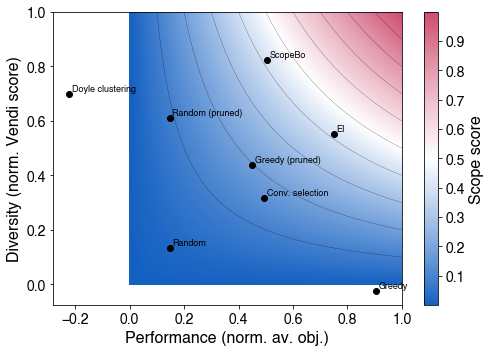

In [ ]:
print("Different Tradeoffs of selection methods")

# set up example values
x = np.linspace(0, 1, 500)
y = np.linspace(0, 1, 500)
X, Y = np.meshgrid(x, y)

# product (scope score)
Z = X * Y

plt.figure(figsize=(7,5))
contourf = plt.contourf(X, Y, Z, levels=500, cmap='Doyle_cont')
contour = plt.contour(X, Y, Z, levels=np.arange(0.1, 1.0, 0.1), colors='k', linewidths=0.2)
x_vals = norm_map_df.loc["Av. norm. objective"]
y_vals = norm_map_df.loc["Norm. Vendi"]

plt.scatter(x_vals, y_vals, color="black", zorder=3)

for col in norm_map_df.columns:
    plt.text(
        x_vals[col] + 0.01,   # small horizontal offset
        y_vals[col] + 0.01,   # small vertical offset
        col,
        fontsize=9)

plt.colorbar(contourf, label="Scope score", ticks = np.arange(0.1, 1.0, 0.1))
plt.xlabel("Performance (norm. av. obj.)")
plt.ylabel("Diversity (norm. Vendi score)")
plt.tight_layout()
plt.show()

### Visualization of scope examples

Show the scopes for the random seed that provides a scope performance closest to the average of all random seeds (for ScopeBO scopes). Scopes for other methods are shown with the same random seed.

In [39]:
def find_av_random_seed(name_results, bounds, batch_pruning, budget=27):
    """Finds the random seed that give the scope with a scope score closet to the average performance."""

    _, dict_dfs_raw_data = Benchmark.get_metric_overview(bounds=bounds,budget=budget,type_results="scope", 
                                name_results=name_results)

    # dict_dfs_raw_data contains the a dict for each batch-pruning 
    # combination which in turn contains a dict of the raw data for the differnt random seeds
    # --> restrict to the relevant data (batch size 2 and no Vendi pruning)
    dfs_raw_data = dict_dfs_raw_data[batch_pruning]

    # collect the scope scores
    # NOTE: the indices are the (zero-indexed) rounds --> round 8 is the full scope of 27 samples
    score_dict = {seed: df.loc[8,"scope"] for seed,df in dfs_raw_data.items()}
    av_score = np.mean(np.array(list(score_dict.values())))

    # calculate the absolute difference to the average score
    score_diff = {seed: abs(score-av_score) for seed,score in score_dict.items()}

    # get the seed that is closest to the average
    av_seed = min(score_diff,key=score_diff.get)

    return av_seed


def get_umap(name_results, objective, hyperpar="balanced_b3_V13", bounds = bounds, seed = None,figsize=(2.7,2.7), show_colorbar=False):

    if seed is None:
        seed = find_av_random_seed(name_results= name_results, bounds=bounds, batch_pruning= "_".join(hyperpar.split("_")[1:]))
    print("Depicted seed:",seed)
    data_labelled = pd.read_csv(f"./arylation_labelled_data.csv",index_col=0)
    obj_max = data_labelled[objective].max()
    obj_min = data_labelled[objective].min()
    Benchmark().track_samples(filename_umap=f"./arylation_UMAP_coords.csv",
                            filename_data=f"27{hyperpar}_s{seed}.csv",
                            bounds=bounds,
                            hide_axis = True, obj_plot_bounds=(obj_max,obj_min),
                            filename_labelled=f"./arylation_labelled_data.csv",
                            name_results= name_results+ "/raw_data", show_colorbar= show_colorbar, objective_mode={"cost":"min"},
                            label_round=False, display_cut_samples=False, figsize = figsize, size_scaling = 0.3, dpi=600, obj_to_display=objective)
    
    return seed

UMAPs for ScopeBO:

UMAP for the objective yield
Depicted seed: 4


Scope score: 0.512
Average objective (scaled on [0,1]-scale): 0.668
Average yield: 34.545
Average cost: 0.090
Vendi score: 16.728


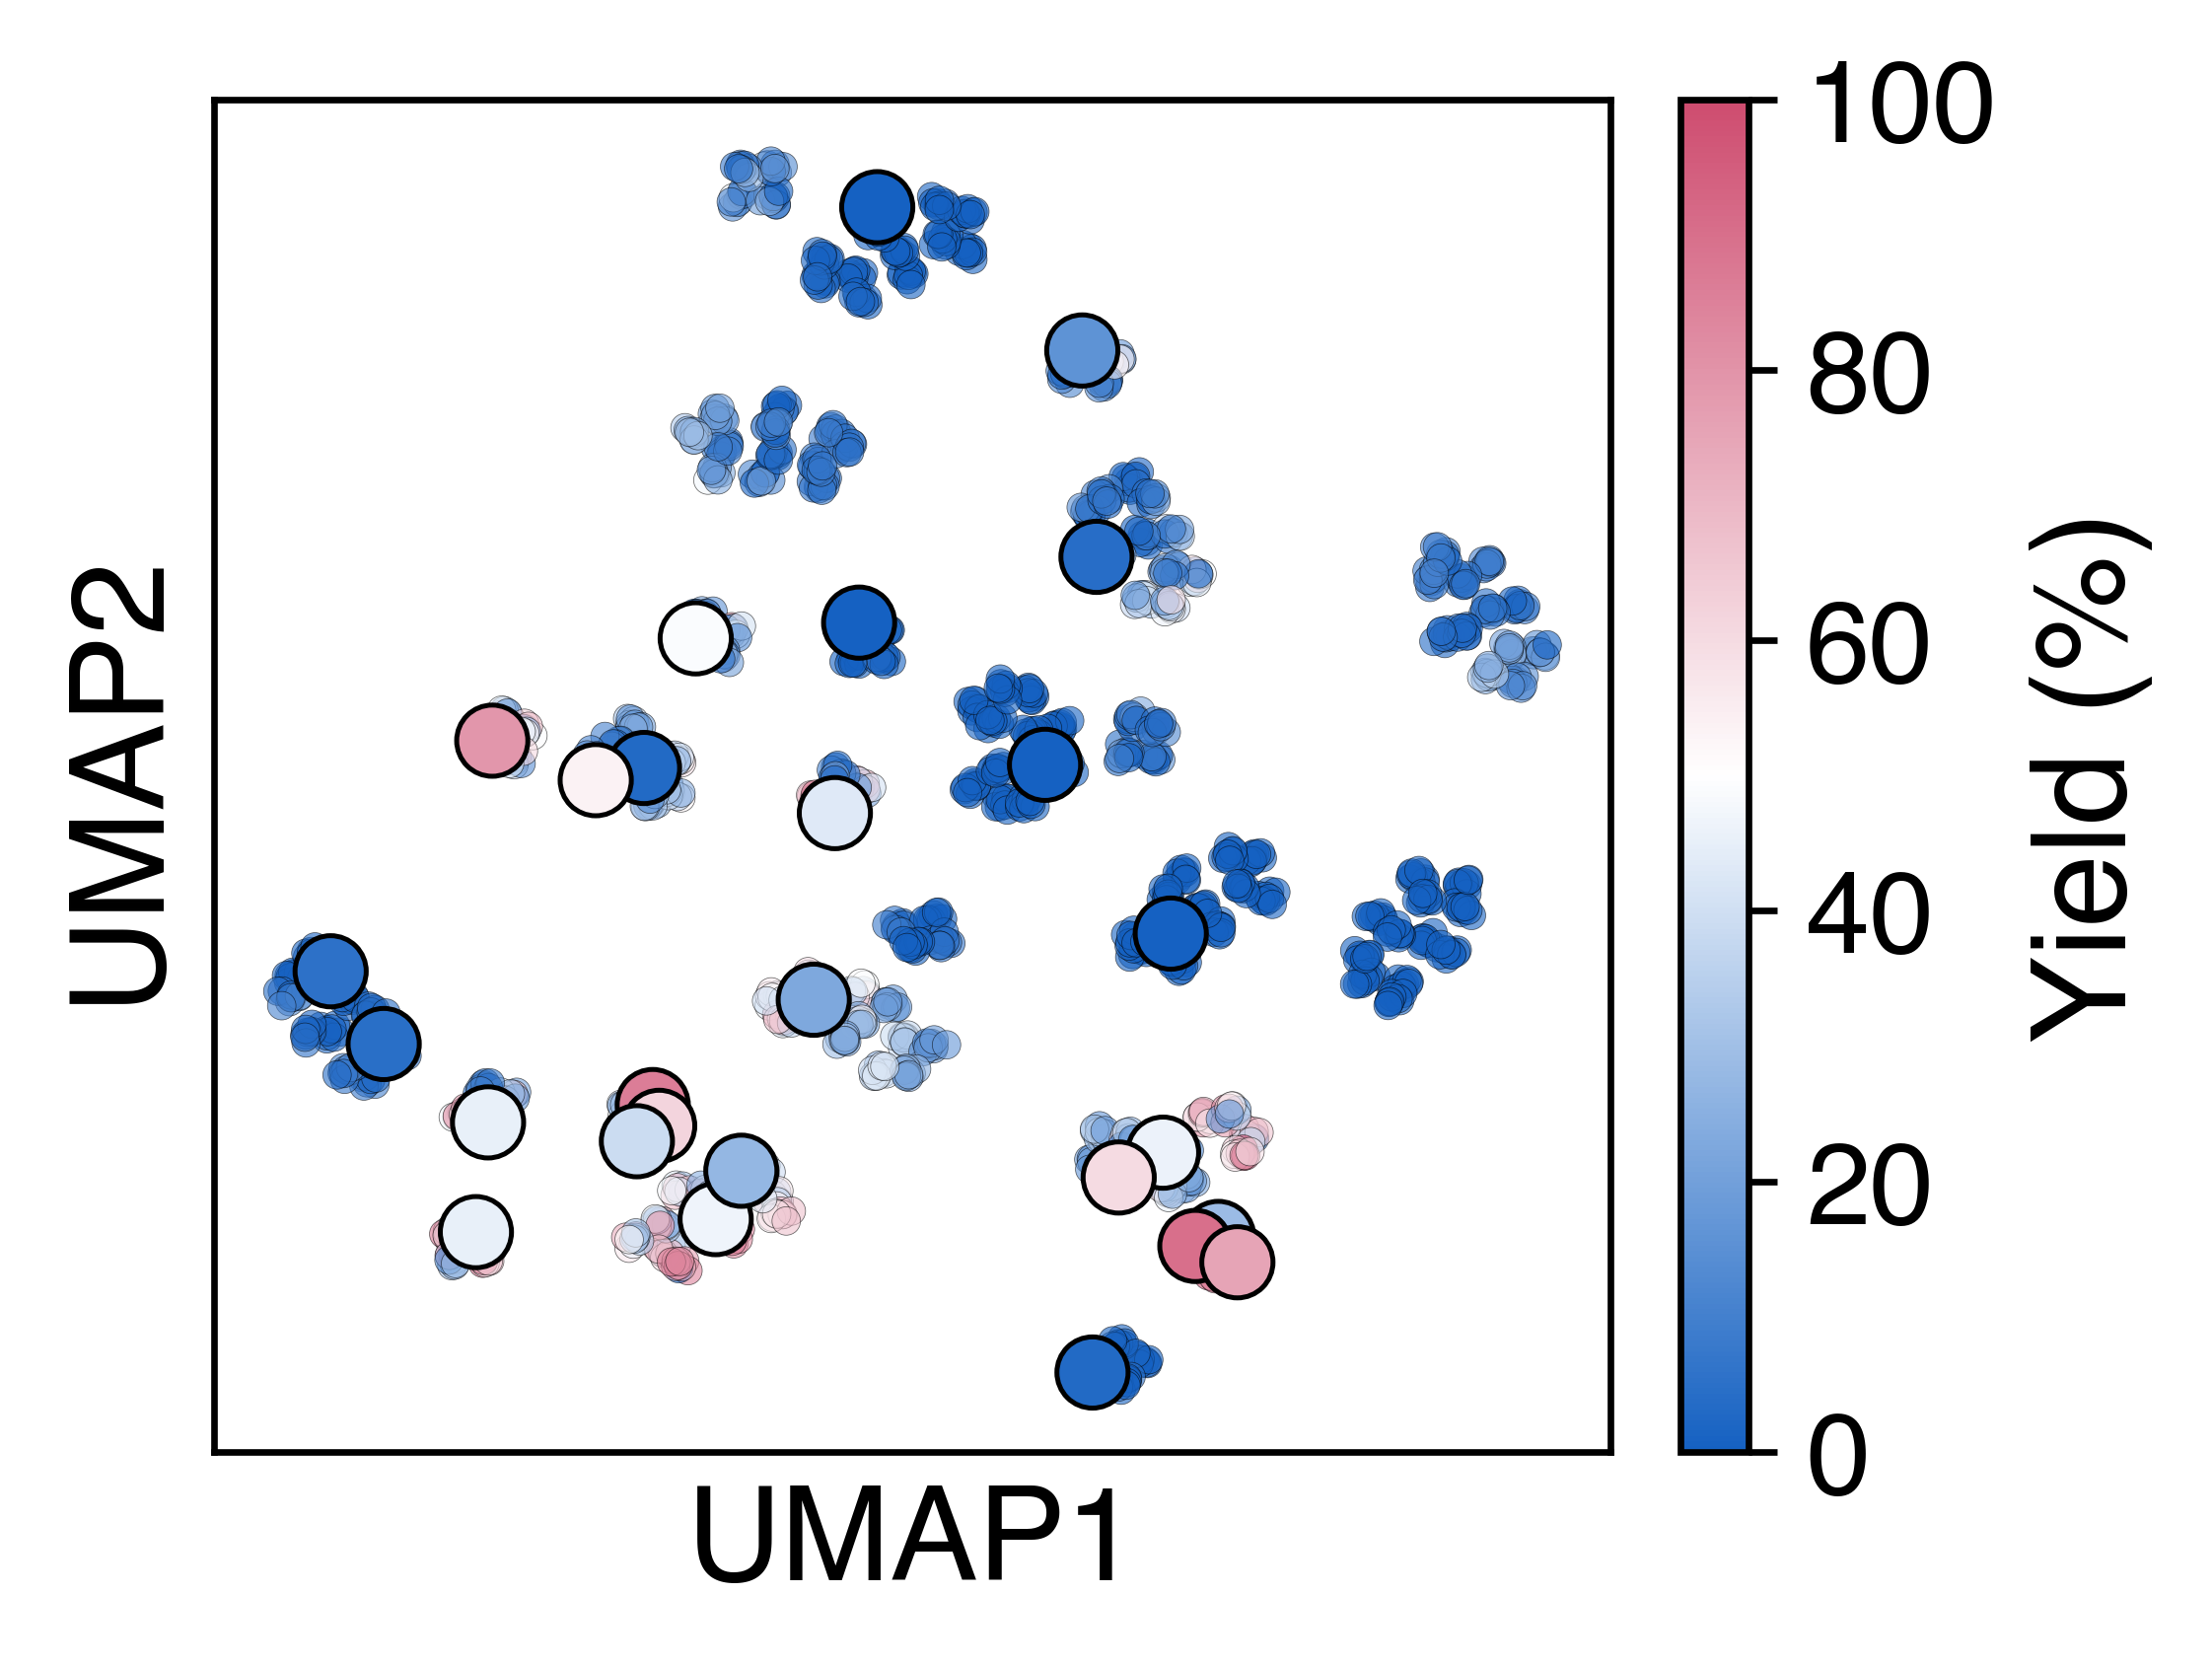

UMAP for the objective cost
Depicted seed: 4
Scope score: 0.512
Average objective (scaled on [0,1]-scale): 0.668
Average yield: 34.545
Average cost: 0.090
Vendi score: 16.728


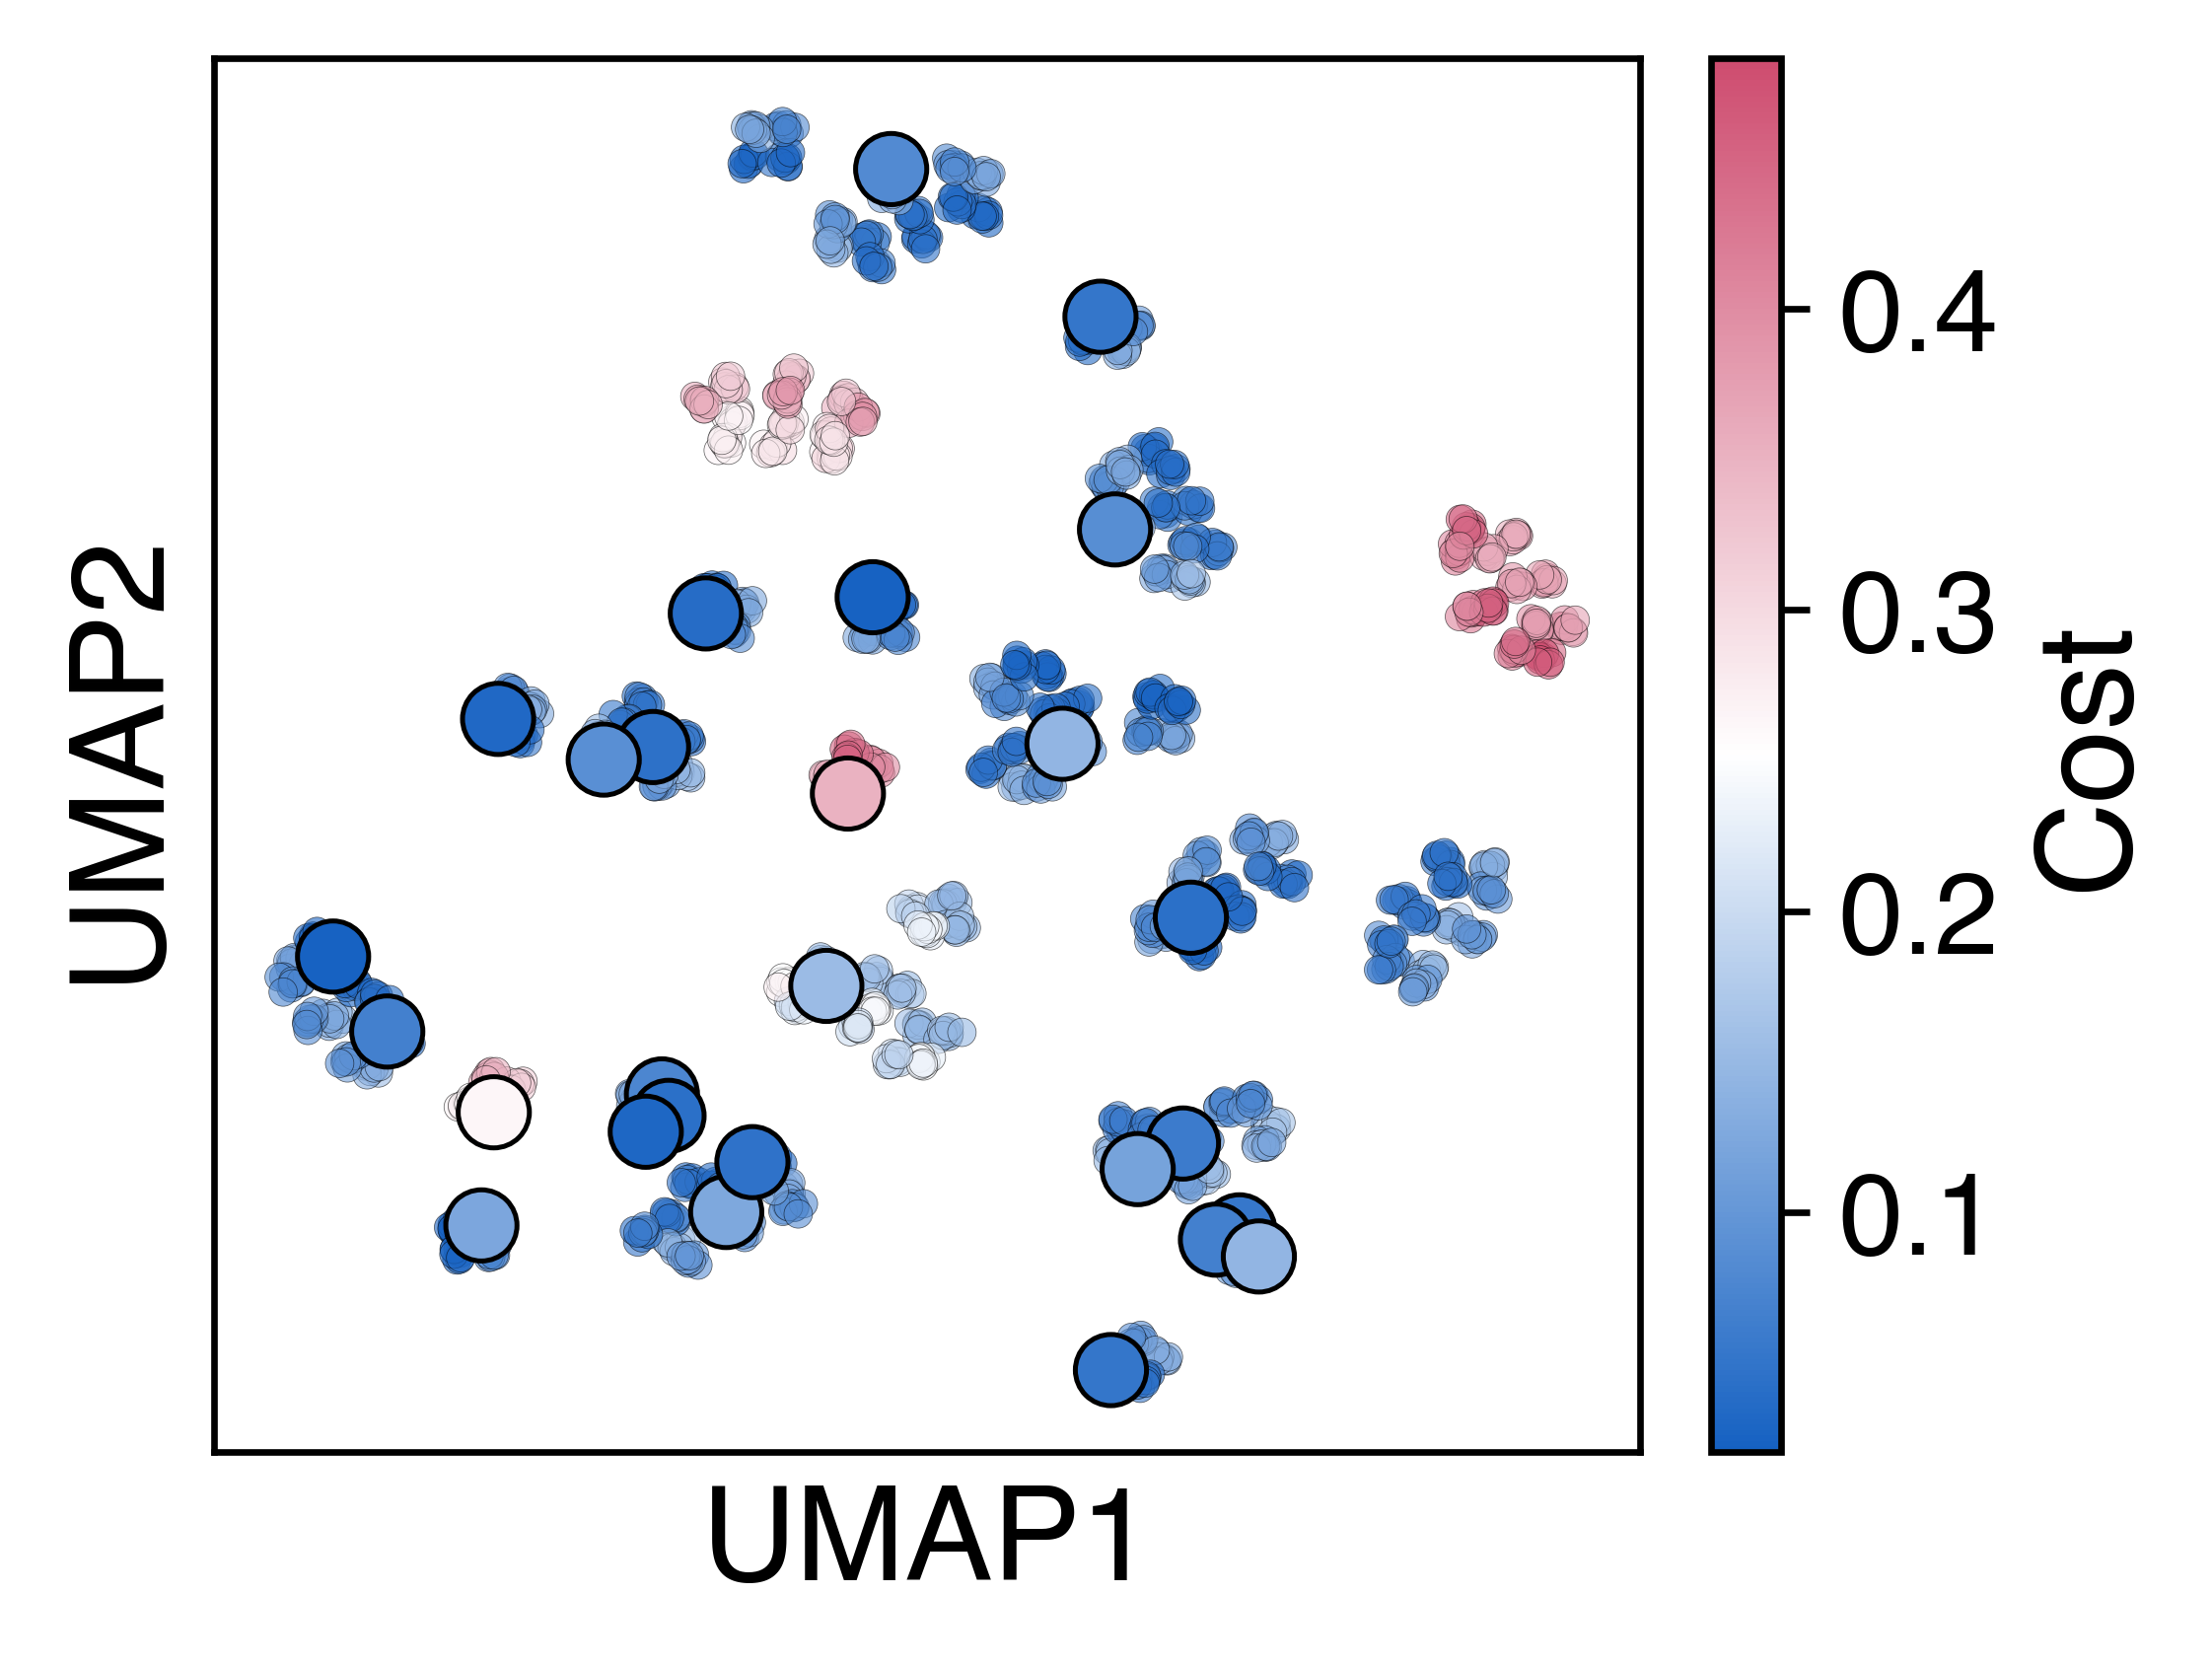

UMAPs for Regular BO (EI):

UMAP for the objective yield
Depicted seed: 4
Scope score: 0.461
Average objective (scaled on [0,1]-scale): 0.810
Average yield: 43.286
Average cost: 0.092
Vendi score: 13.670


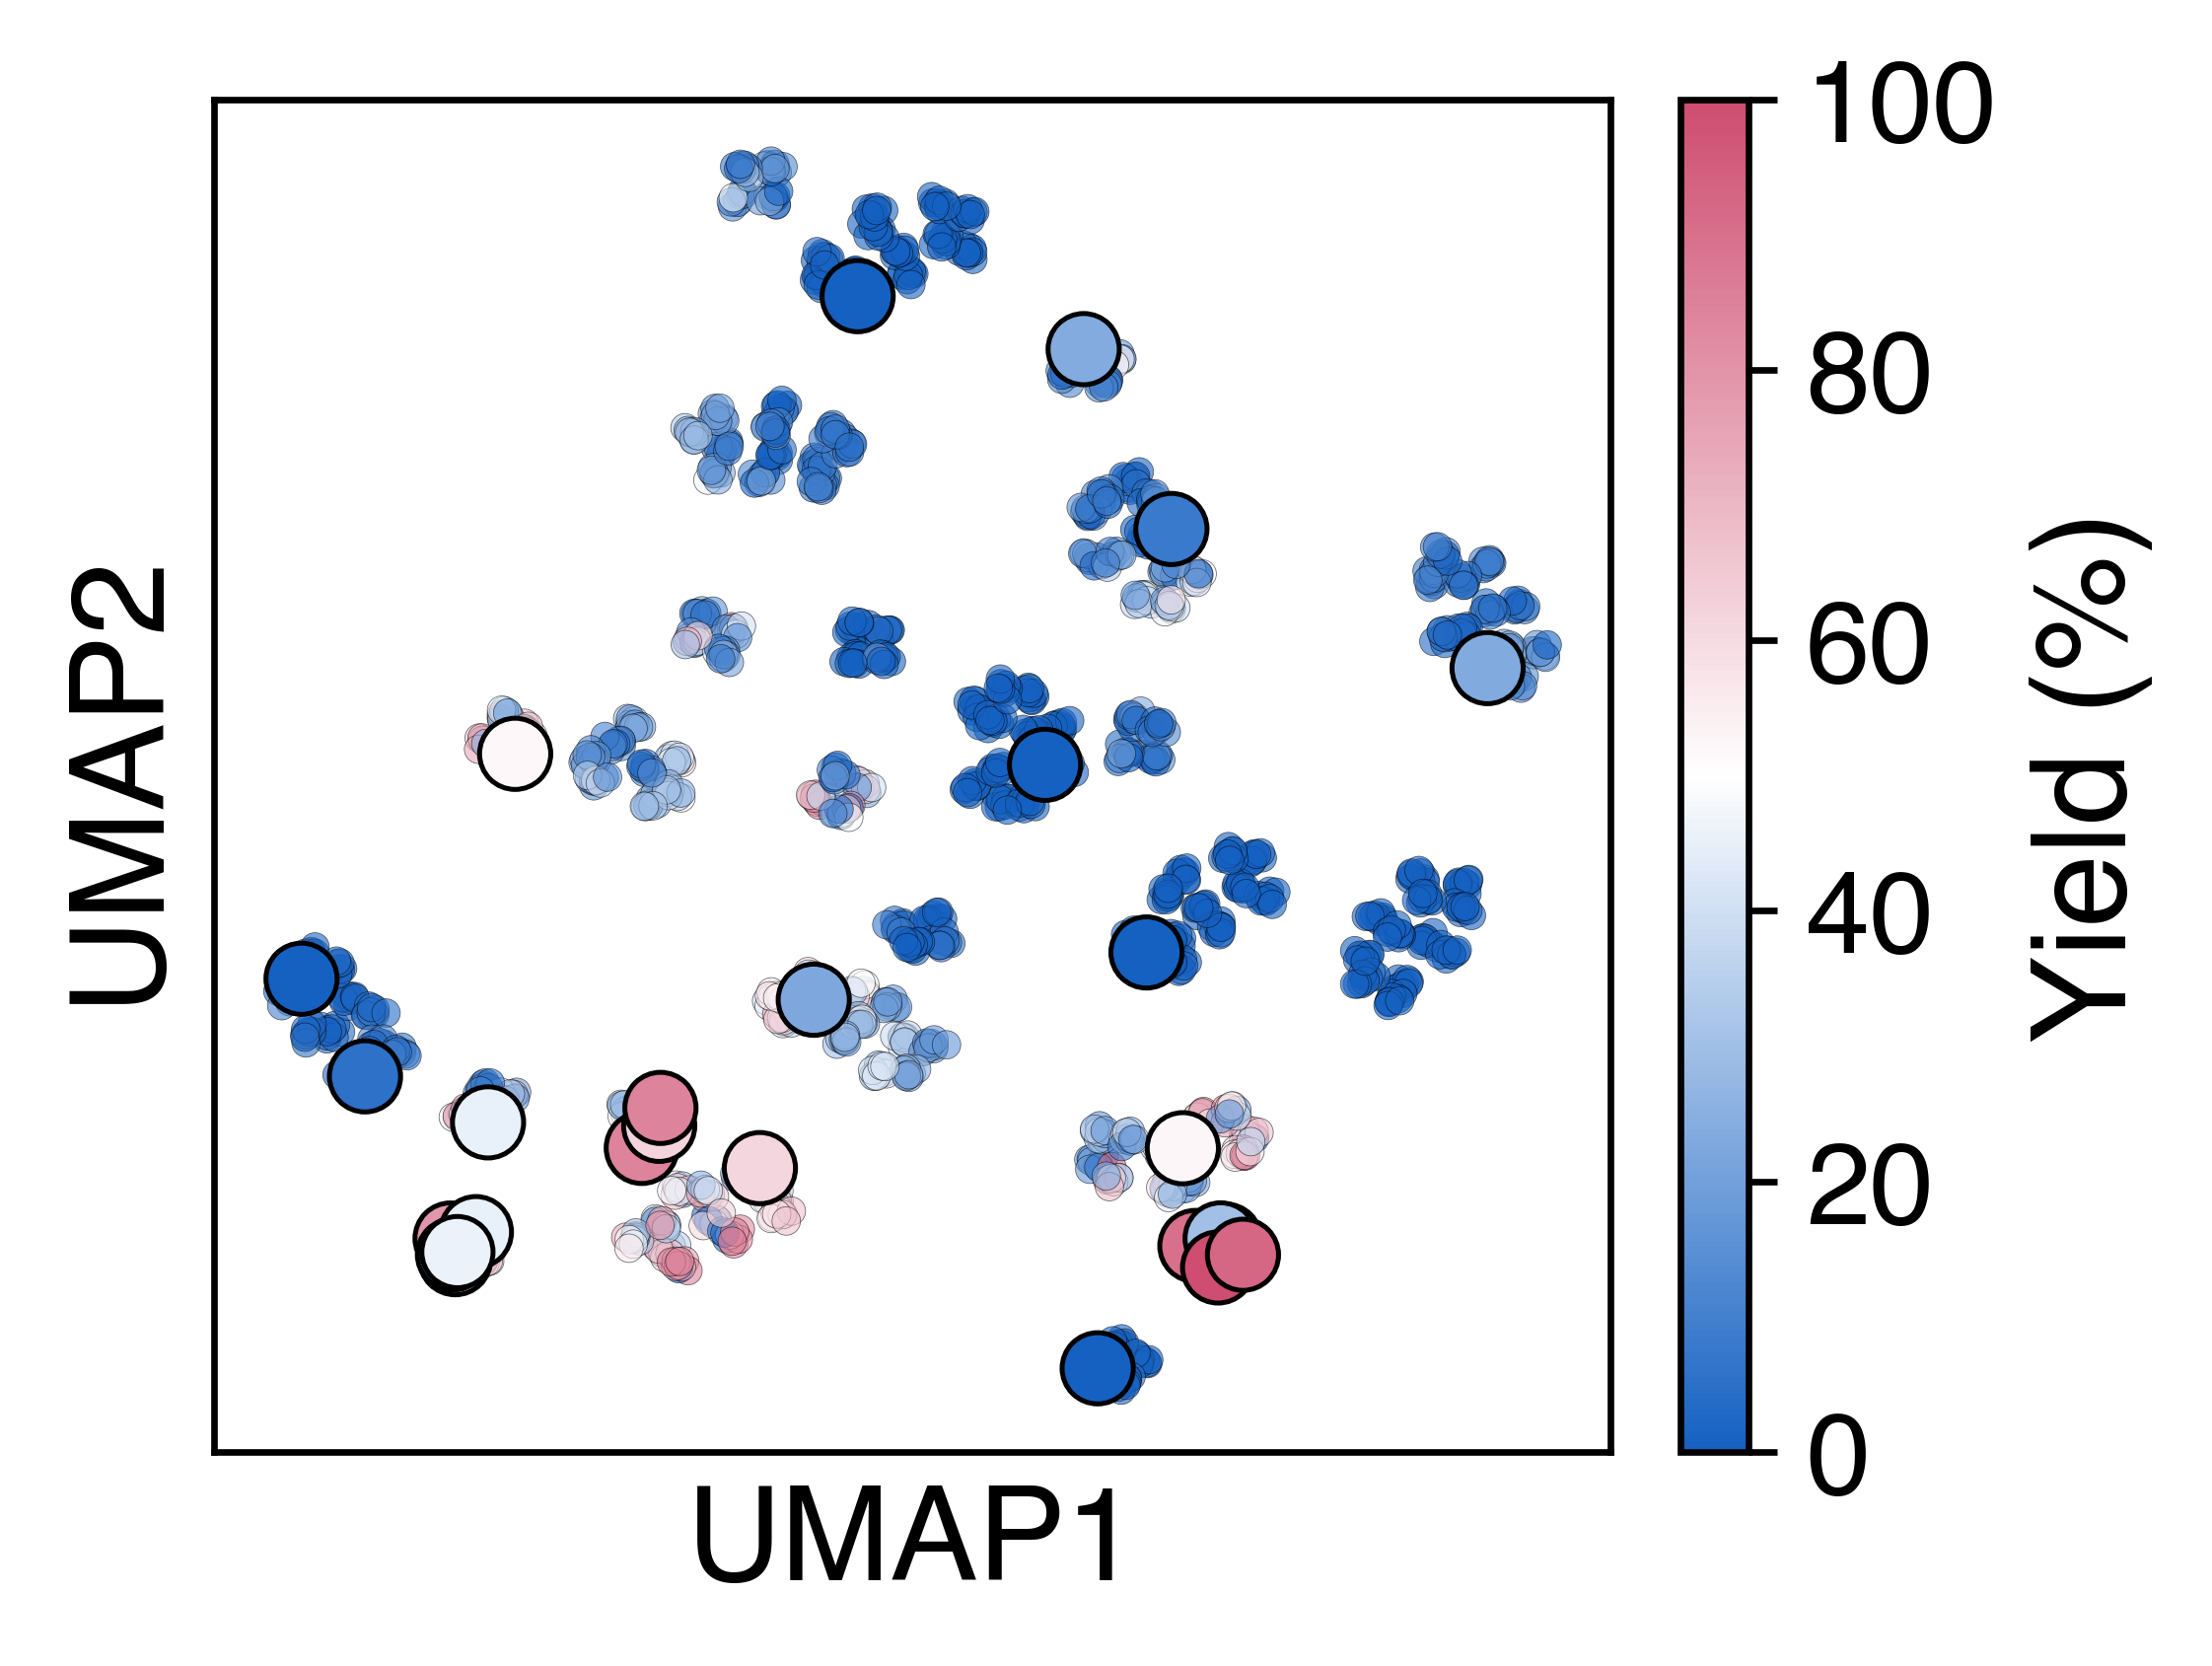

UMAP for the objective cost
Depicted seed: 4
Scope score: 0.461
Average objective (scaled on [0,1]-scale): 0.810
Average yield: 43.286
Average cost: 0.092
Vendi score: 13.670


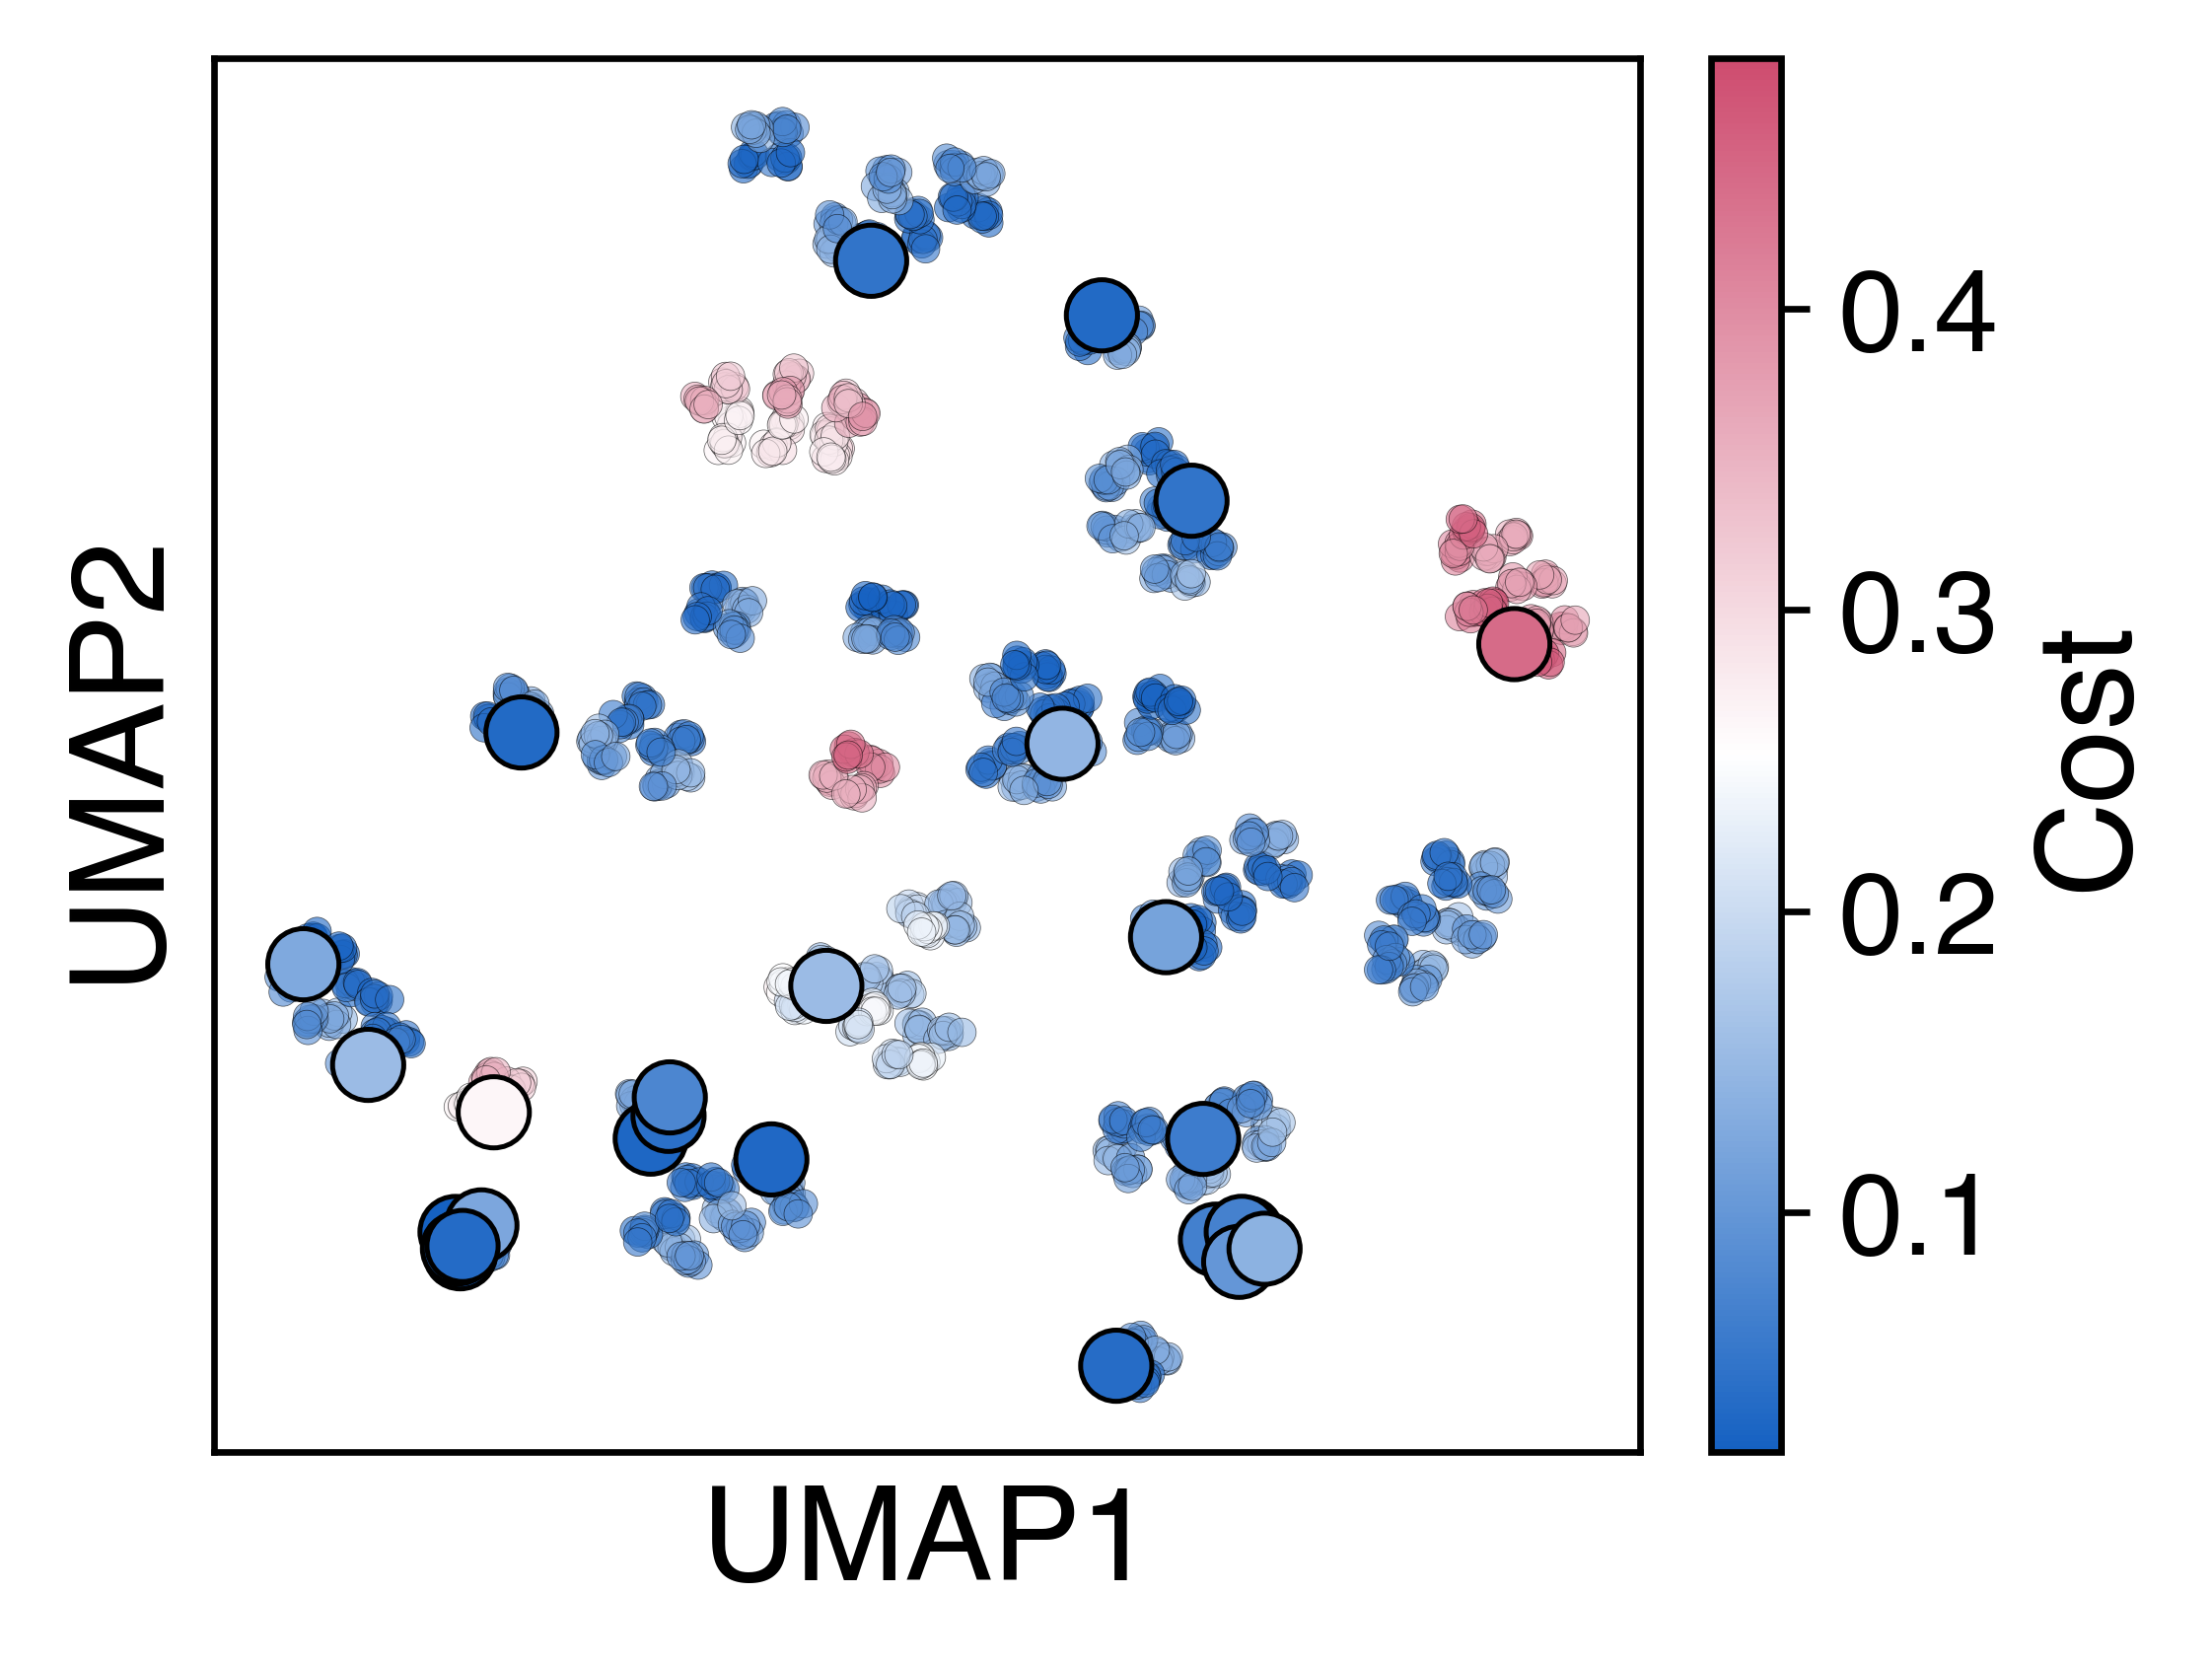

UMAPs for conventional selection:

UMAP for the objective yield
Depicted seed: 4
Scope score: 0.159
Average objective (scaled on [0,1]-scale): 0.519
Average yield: 35.431
Average cost: 0.116
Vendi score: 9.602


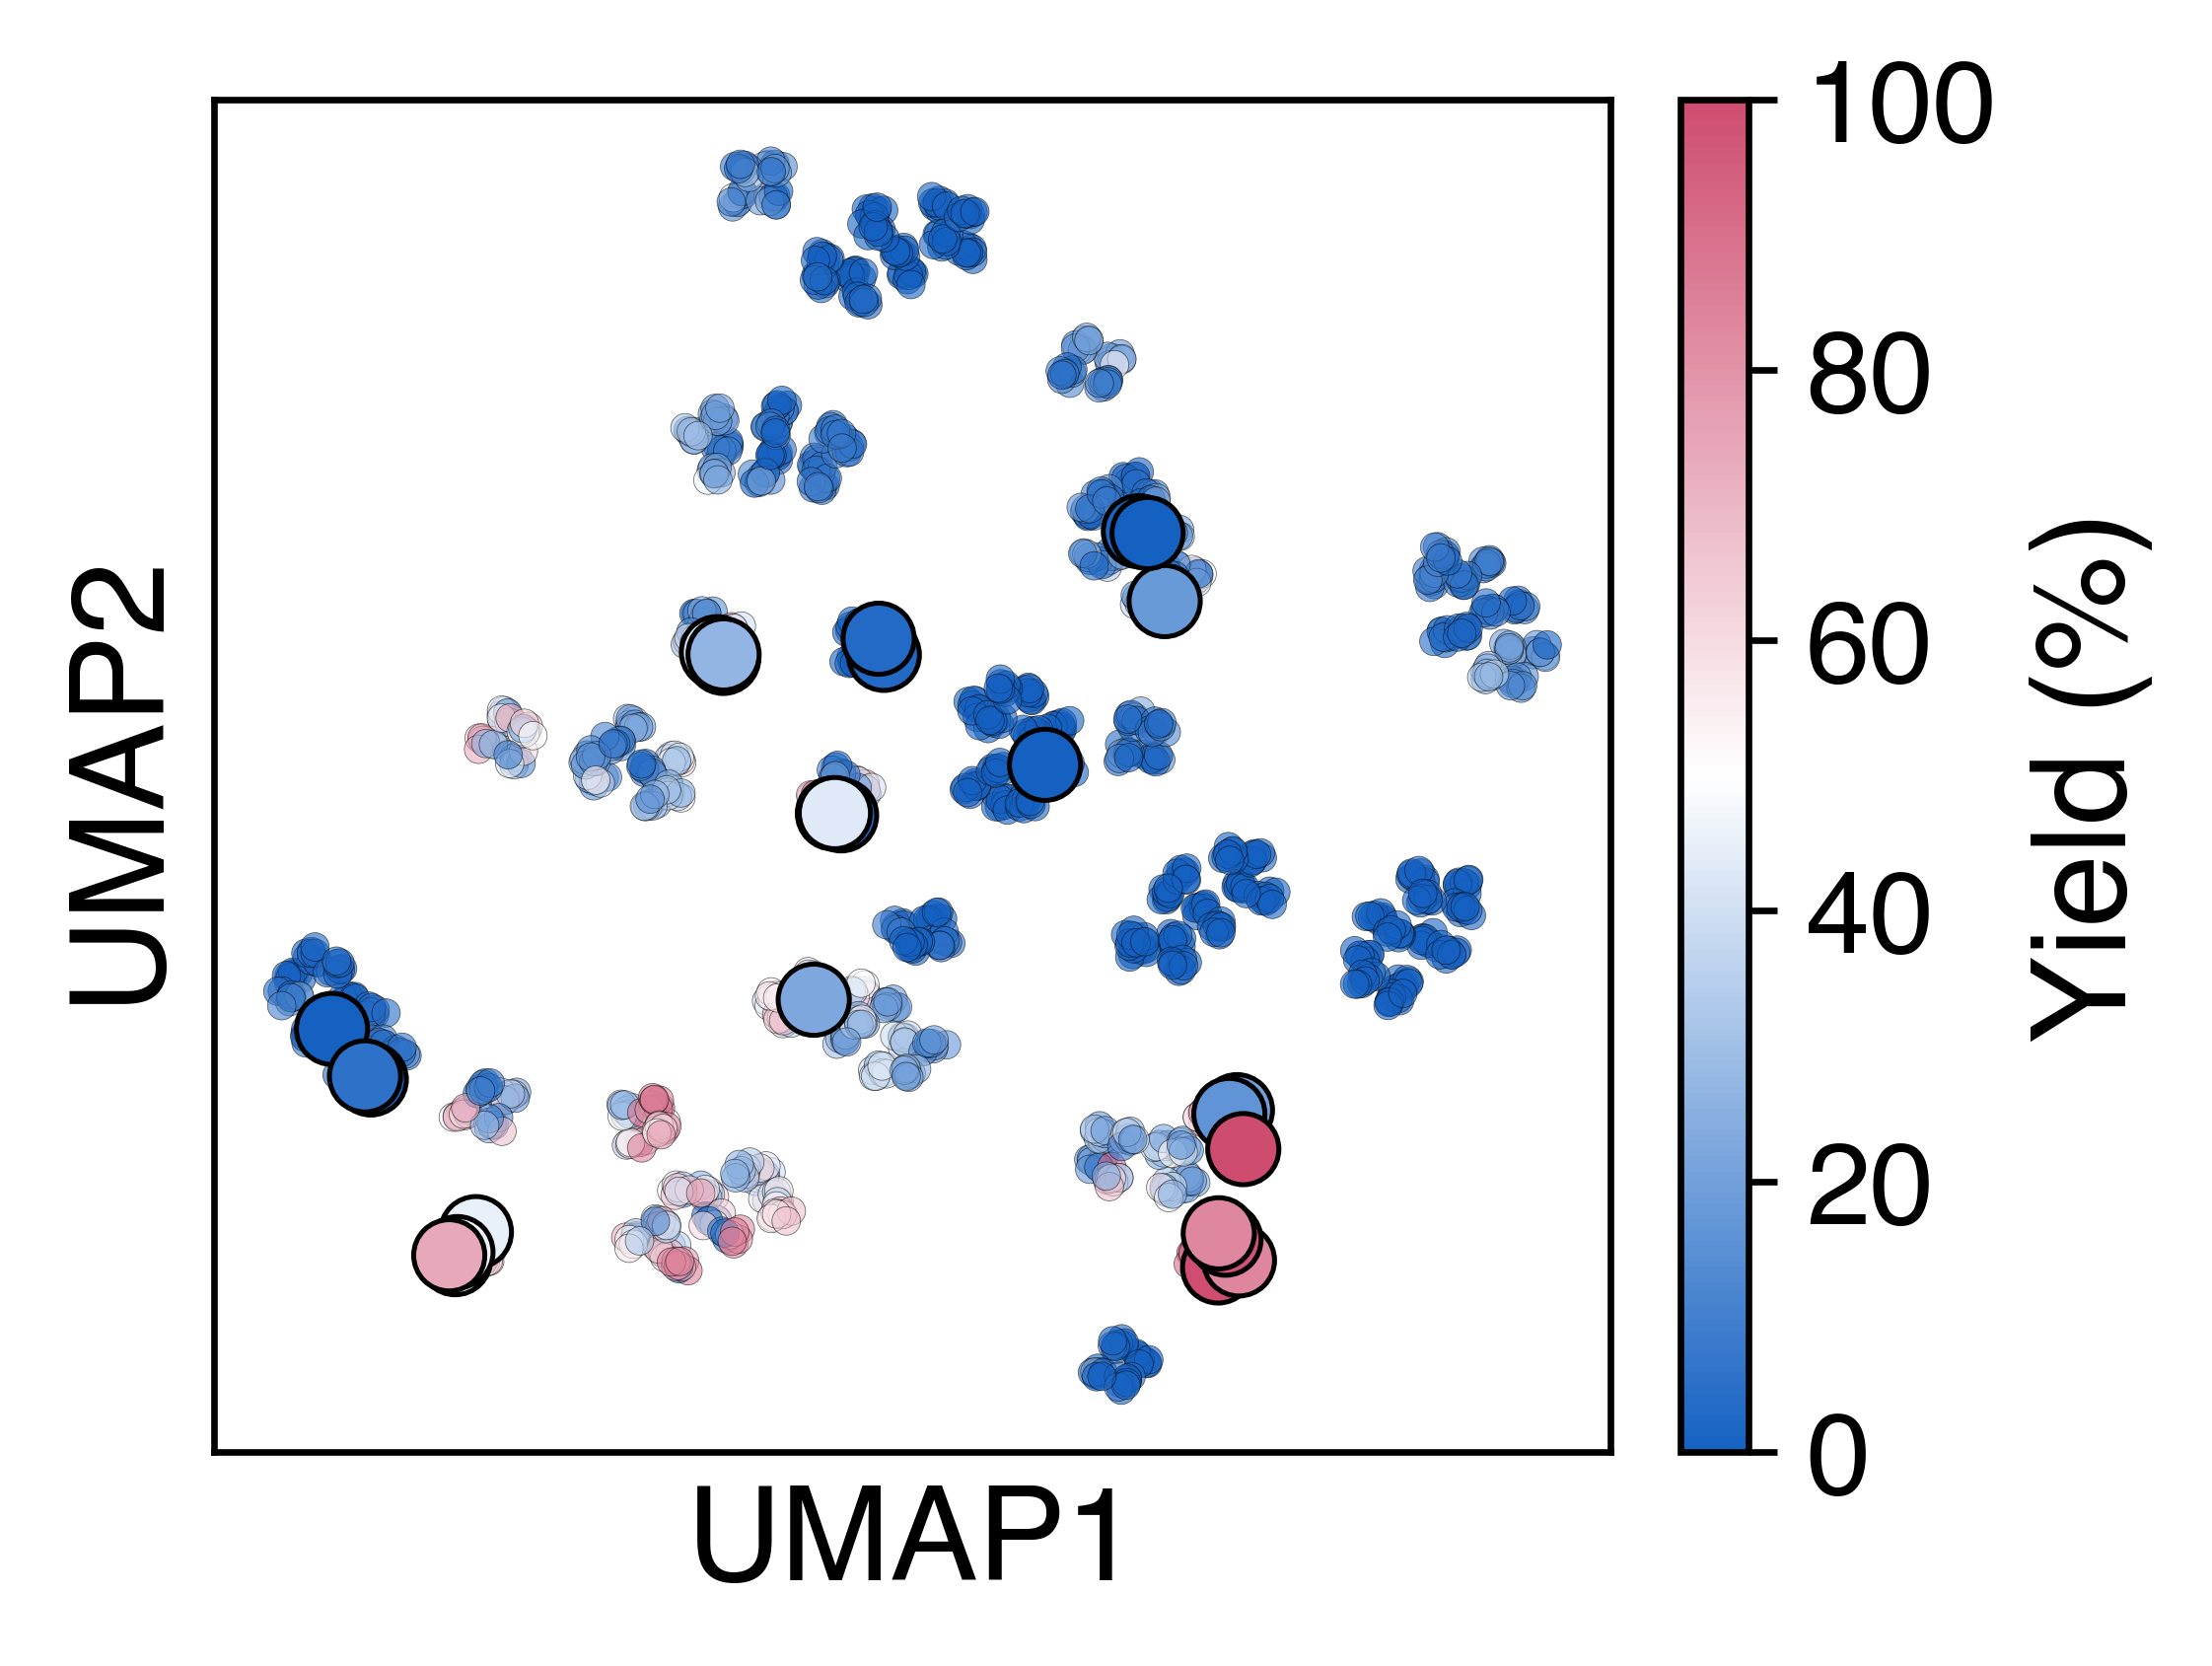

UMAP for the objective cost
Depicted seed: 4
Scope score: 0.159
Average objective (scaled on [0,1]-scale): 0.519
Average yield: 35.431
Average cost: 0.116
Vendi score: 9.602


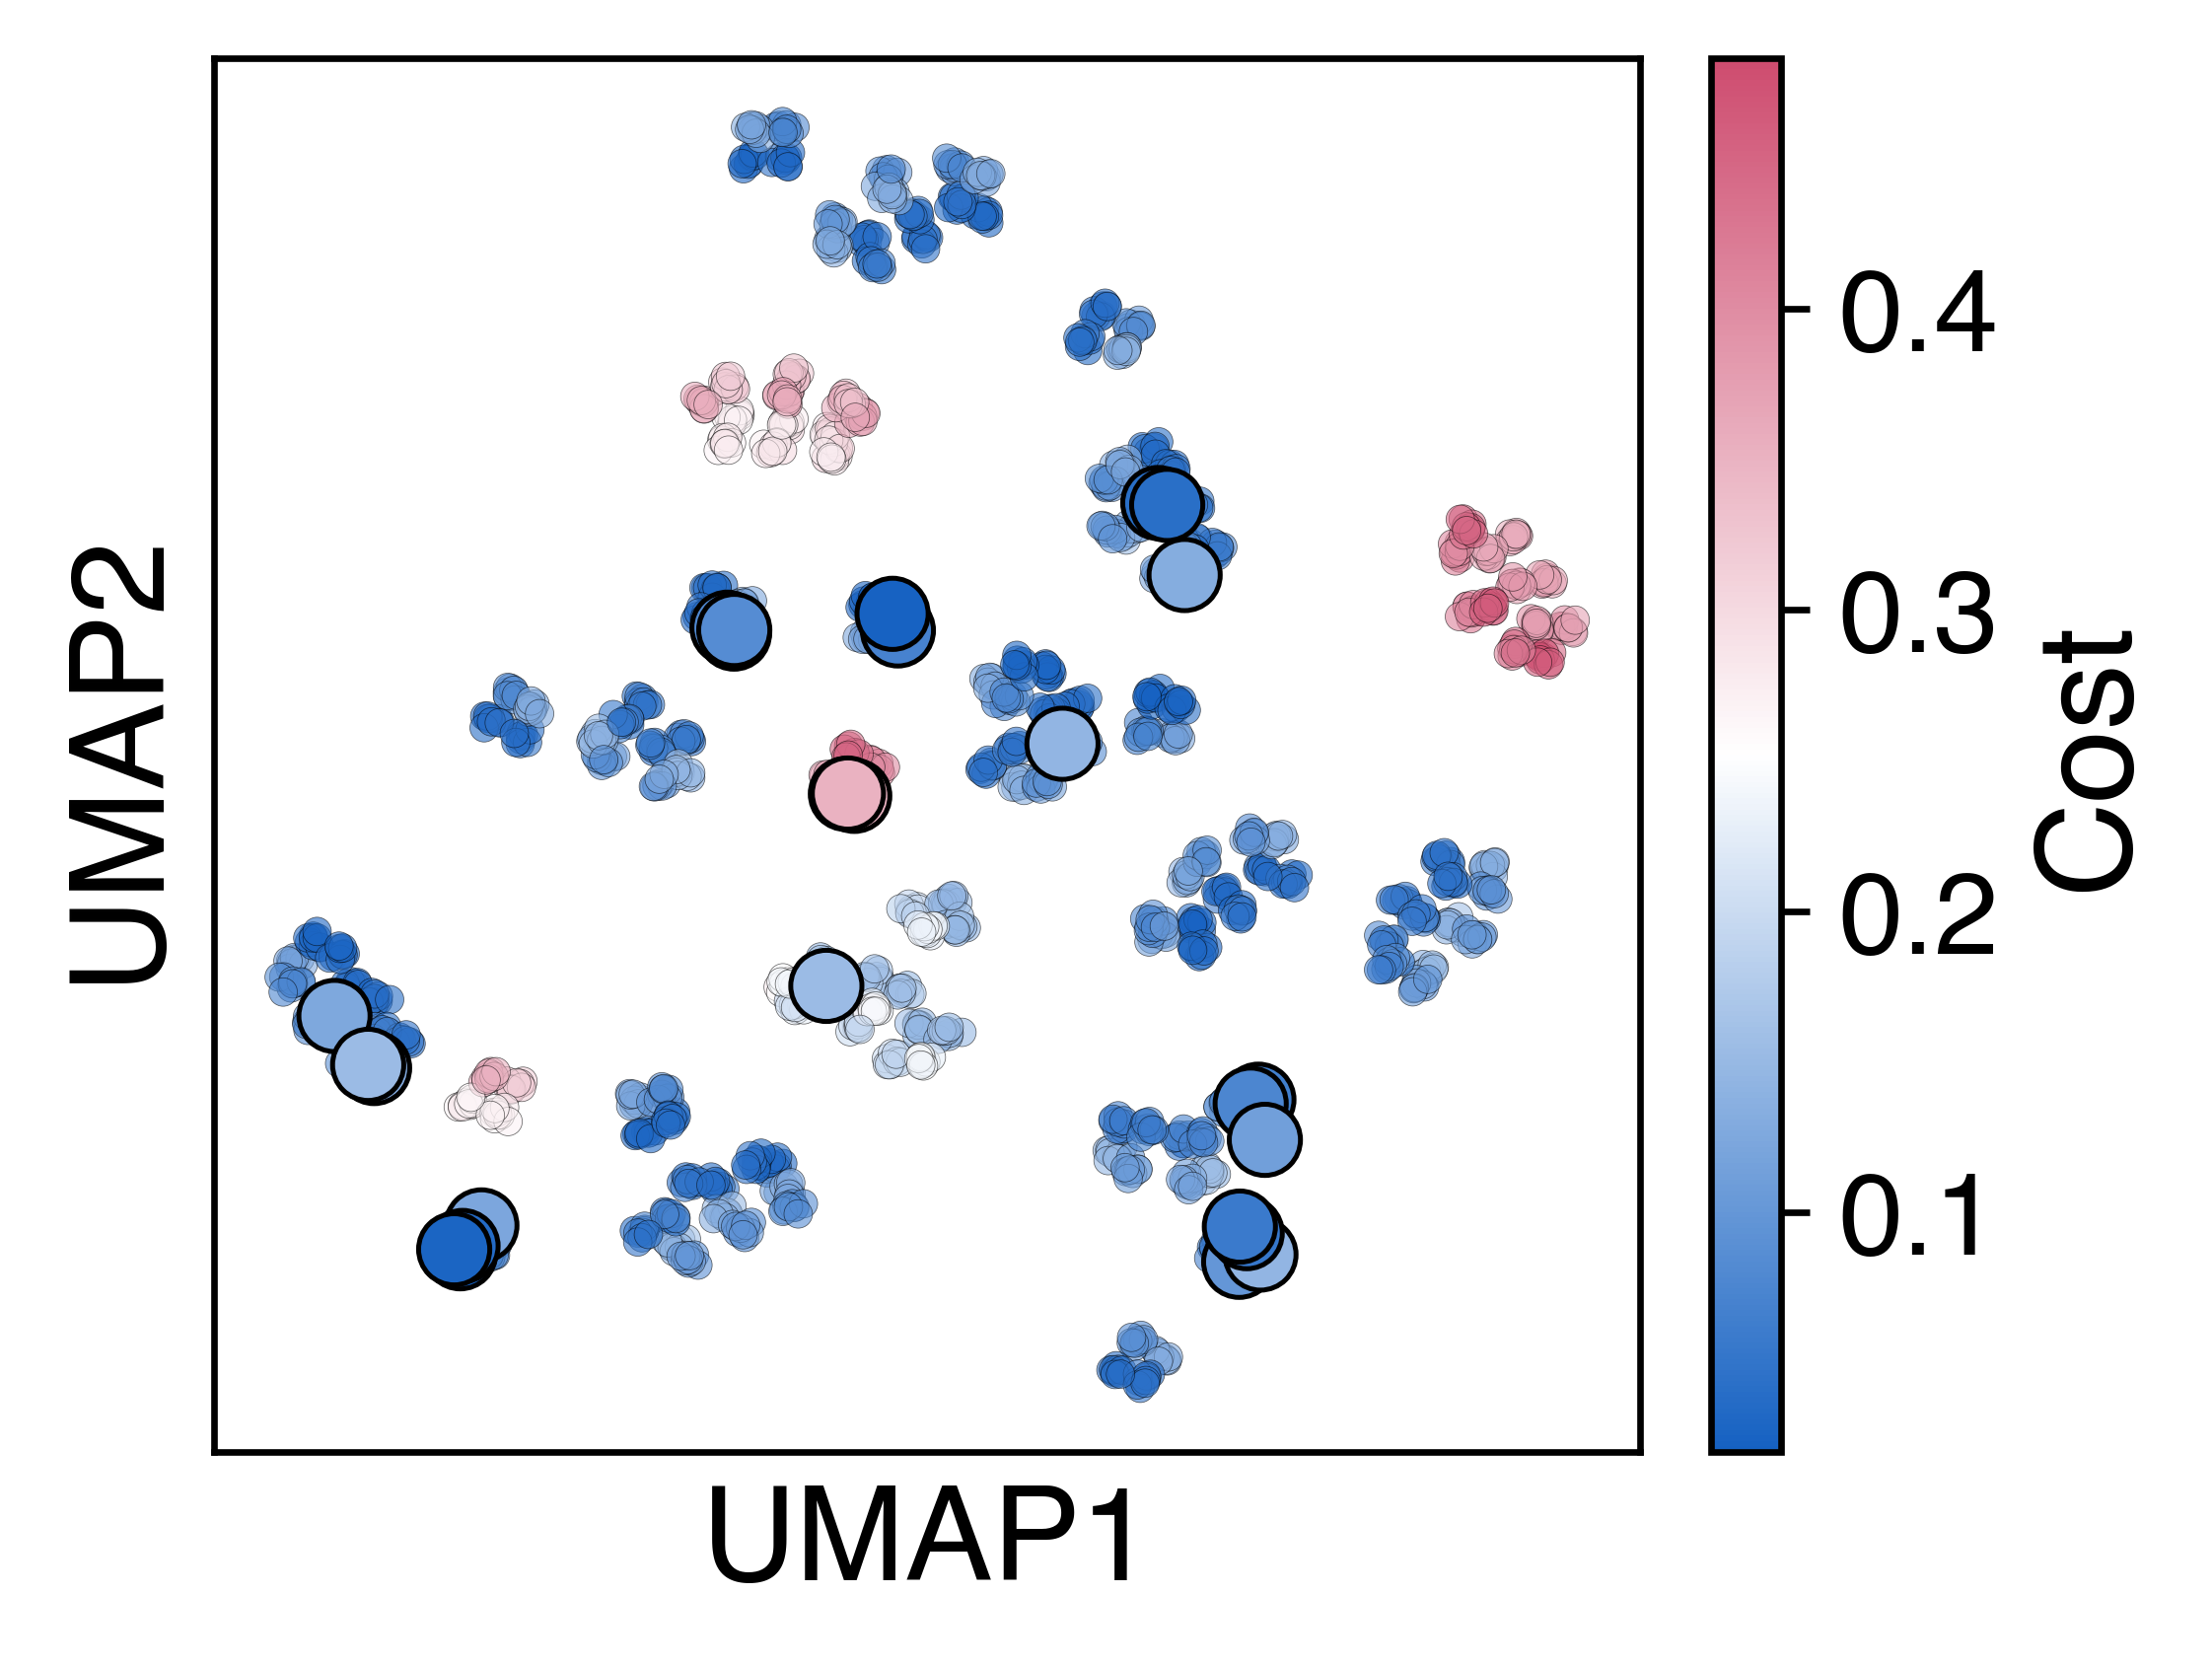

In [40]:
print(f"UMAPs for ScopeBO:\n")
seed = None
for obj in objectives:
    print(f"UMAP for the objective {obj}")
    seed = get_umap(name_results=f"./Results_Data/scope_balanced_pruning", bounds=bounds, figsize = (3.63, 2.7), objective = obj, show_colorbar=True)
print(f"UMAPs for Regular BO (EI):\n")
for obj in objectives:
    print(f"UMAP for the objective {obj}")
    get_umap(name_results=f"./Results_Data/scope_balanced_no-pruning", bounds = bounds, hyperpar="balanced_b3_V0", 
             seed=seed, figsize = (3.63, 2.7), objective = obj, show_colorbar=True)
print(f"UMAPs for conventional selection:\n")
for obj in objectives:
    print(f"UMAP for the objective {obj}")
    get_umap(name_results=f"./Results_Data/scope_human-like-acq", hyperpar="greedy_b3_V5", seed = seed, bounds = bounds, figsize = (3.63, 2.7), show_colorbar=True, objective = obj)

Most of the EI baseline samples are concentrated on a high performing cluster. The conventional scope displays this behavior even more strongly. The ScopeBO algorithm also sampled this cluster to gain information about its high performance, but more evenly sampled the rest of the chemical space, leading a significantly improved Vendi score.